# Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **_Hardani Ismu Nabil_** | _hardani.ismu.n@gmail.com_ | **_ND Stadium Collaborative Project 2025/2026_** |

# Notebook Target Definition

* **GOAL** Analyze the correlated dataset for WhatsApp and Instagram
* **GENERATES** metric graphs such as the CDFs of Browsing Tests
  * The paper used figures from the last two section: Visualization and Text output
* **REQUIRES** SigCap Data Processing notebooks to be run first! It will create data/process/SigCapCorrelated directory if successful

# ===============================
# ===============================

# A- Notebook Setup

In [1]:
import gc
import os
import pathlib

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Force Matplotlib to use Type 42 (TrueType) fonts instead of Type 3
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Ensure text isn't converted to paths/bitmaps
matplotlib.rcParams['svg.fonttype'] = 'none'

In [2]:
PROJECT_ROOT = pathlib.Path('.').cwd().parent # you can also do it manually, for example ~/repos/NdSta2026


print('='*50, '[DATA DIRECTORY]')
DATA_DIR_WA = PROJECT_ROOT / 'data_processed'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR_WA}")

print('='*50, '[DATA DIRECTORY]')
DATA_DIR_IG = PROJECT_ROOT / 'data_processed'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Looking for data in: {DATA_DIR_IG}")


print('- '*25)
print('='*50, '[OUTPUT DIRECTORY]')

# OUTPUT_DIR = PROJECT_ROOT / 'output/output_July1st_dataAnalysis/analysis_IgWaStatistics' # CHANGE this into the notebook file name
OUTPUT_DIR = PROJECT_ROOT / 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"All outputs will be in: {OUTPUT_DIR}")

================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_processed
================================================== [DATA DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
Looking for data in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/data_processed
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================================== [OUTPUT DIRECTORY]
Project Root: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis
All outputs will be in: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/figures


In [3]:
df_whatsapp_game_raw = pd.read_csv(DATA_DIR_WA / 'df_whatsapp_merged_gd6.csv')
df_whatsapp_empty_raw = pd.read_csv(DATA_DIR_WA / 'df_messaging_merged_pg.csv')

df_instagram_game_raw = pd.read_csv(DATA_DIR_IG / 'df_instagram_merged_gd6.csv')
df_instagram_empty_raw = pd.read_csv(DATA_DIR_IG / 'df_instagram_merged_pg.csv')


## B- Data Filtering
by Collection column

In [4]:
# Label the browser data
df_whatsapp_empty = df_whatsapp_empty_raw[df_whatsapp_empty_raw['Collection'] == '20260226_preGame_Bowl'].copy()
df_whatsapp_empty['Label'] = 'Non-game'

df_instagram_empty = df_instagram_empty_raw[df_instagram_empty_raw['Collection'] == '20260226_preGame_Bowl'].copy()
df_instagram_empty['Label'] = 'Non-game'

df_whatsapp_game = df_whatsapp_game_raw[df_whatsapp_game_raw['Location_sigcap'] == 'Bowl'].copy()
df_whatsapp_game['Label'] = 'Game'

df_instagram_game = df_instagram_game_raw[df_instagram_game_raw['Location_sigcap'] == 'Bowl'].copy()
df_instagram_game['Label'] = 'Game'

In [5]:
combined_whatsapp_df = pd.concat([df_whatsapp_empty, df_whatsapp_game], ignore_index=True)
combined_instagram_df = pd.concat([df_instagram_empty, df_instagram_game], ignore_index=True)
gc.collect()

0

In [6]:
combined_instagram_df['Duration (fallbacked)'] = np.where(combined_instagram_df['Duration'].isna(), 30, combined_instagram_df['Duration'])
combined_whatsapp_df['Duration (fallbacked)'] = np.where(combined_whatsapp_df['Send Duration'].isna(), 30, combined_whatsapp_df['Send Duration'])

# ===============================
# ===============================

# C1- Text Output, Whatsapp, Send Text

In [7]:
df_whatsapp_gameday = combined_whatsapp_df[combined_whatsapp_df['Label'] == 'Game']
df_whatsapp_postgame = combined_whatsapp_df[combined_whatsapp_df['Label'] == 'Non-game']

df_whatsapp_gameday = df_whatsapp_gameday[df_whatsapp_gameday['Action Type'] == 'Send Picture']
df_whatsapp_postgame = df_whatsapp_postgame[df_whatsapp_postgame['Action Type'] == 'Send Picture']

In [8]:
df_whatsapp_postgame['Time'] = pd.to_datetime(df_whatsapp_postgame['Time'])
# df_whatsapp_postgame['Time'].describe()

### B: Overview

In [9]:
# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#        'Receive Time', 'Transmission Status', 'Delivery Status',
#        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('Gameday' + '='*30)
# display(df_whatsapp_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(df_whatsapp_postgame[cols].describe())

### B: Operator-wise

In [10]:
att_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'AT&T'].copy()
att_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'AT&T'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#        'Receive Time', 'Transmission Status', 'Delivery Status',
#        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[AT&T]'+'-'*50)
# print('Gameday' + '='*30)
# display(att_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(att_postgame[cols].describe())

In [11]:
tmo_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'T-Mobile'].copy()
tmo_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'T-Mobile'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#         'Receive Time', 'Transmission Status', 'Delivery Status',
#         'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[T-MOBILE]'+'-'*50)
# print('Gameday' + '='*30)
# display(tmo_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(tmo_postgame[cols].describe())

In [12]:
vzw_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Verizon'].copy()
vzw_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Verizon'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#         'Receive Time', 'Transmission Status', 'Delivery Status',
#         'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[VERIZON]'+'-'*50)
# print('Gameday' + '='*30)
# display(vzw_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(vzw_postgame[cols].describe())

In [13]:
wifi6_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Wi-Fi 6'].copy()
wifi6_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Wi-Fi 6'].copy()

cols = ['Send Duration', 'Delivery Duration', 'Start Time',
        'Receive Time', 'Transmission Status', 'Delivery Status',
        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[Wi-Fi 6 GHz]'+'-'*50)
# print('Gameday' + '='*30)
# display(wifi6_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(wifi6_postgame[cols].describe())

In [14]:
wifi5_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Wi-Fi 5'].copy()
wifi5_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Wi-Fi 5'].copy()

cols = ['Send Duration', 'Delivery Duration', 'Start Time',
        'Receive Time', 'Transmission Status', 'Delivery Status',
        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[Wi-Fi 5 GHz]'+'-'*50)
# print('Gameday' + '='*30)
# display(wifi5_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(wifi5_postgame[cols].describe())

### B: Descriptive Statistics

In [15]:
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats


def ultra_simple_load_test(df, metric_col, metric_name, unit, ci_level=0.95, debug=False):
    """
    Statistical load test comparing Gameday vs PostGame periods
    
    Parameters:
    -----------
    df : DataFrame
        Contains 'Period' column and the metric column
    metric_col : str
        Column name in df for the metric (e.g., 'Time To First Byte_s')
    metric_name : str
        Display name for the metric (e.g., 'Time to First Byte')
    unit : str
        Unit for the metric (e.g., 's', 'ms', 'Gbps', 'MB/s')
    ci_level : float
        Confidence level for intervals (default 0.95)
    debug : bool
        Print debug information
    """
    
    if debug:
        print(f"[DEBUG] Starting analysis for: {metric_name}")
        print(f"[DEBUG] Column: {metric_col}, Unit: {unit}")
        print(f"[DEBUG] DataFrame shape: {df.shape}")
        print(f"[DEBUG] Columns available: {df.columns.tolist()}")
    
    # Filter valid samples
    valid = df[
        (df['Test Status'] == 'Completed') & 
        (df[metric_col].notna())
    ].copy()
    
    if debug:
        print(f"[DEBUG] Valid samples after filtering: {len(valid)}")
        print(f"[DEBUG] Test Status counts: {df['Test Status'].value_counts().to_dict()}")
        print(f"[DEBUG] Period counts in valid: {valid['Period'].value_counts().to_dict()}")
    
    if len(valid) == 0:
        return {"Error": "No valid samples"}
    
    # Split by period
    gd = valid[valid['Period'] == 'Gameday'][metric_col]
    pg = valid[valid['Period'] == 'PostGame'][metric_col]
    
    if debug:
        print(f"[DEBUG] Gameday samples: {len(gd)}")
        print(f"[DEBUG] PostGame samples: {len(pg)}")
        print(f"[DEBUG] Gameday stats - min: {gd.min():.4f}, max: {gd.max():.4f}, median: {gd.median():.4f}")
        print(f"[DEBUG] PostGame stats - min: {pg.min():.4f}, max: {pg.max():.4f}, median: {pg.median():.4f}")
    
    # # Minimum sample size check
    # if len(gd) < 10 or len(pg) < 10:
    #     return {"Error": f"Insufficient samples: GD={len(gd)}, PG={len(pg)} (need at least 10 each)"}
    
    # Mann-Whitney U test
    try:
        _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
        if debug:
            print(f"[DEBUG] Mann-Whitney U test p-value: {pval:.6f}")
    except Exception as e:
        if debug:
            print(f"[DEBUG] Mann-Whitney test failed: {e!s}")
        return {"Error": f"Statistical test failed: {e!s}"}
    
    # Hodges-Lehmann estimator and bootstrap CI
    try:
        # Calculate all pairwise differences
        differences = np.array([x - y for x in gd for y in pg])
        hl_estimate = np.median(differences)
        
        if debug:
            print(f"[DEBUG] Hodges-Lehmann estimate: {hl_estimate:.6f}")
            print(f"[DEBUG] Number of pairwise differences: {len(differences):,}")
        
        # Bootstrap for confidence interval
        n_bootstrap = 1000
        bootstrap_diffs = []
        
        for i in range(n_bootstrap):
            gd_boot = np.random.choice(gd, size=len(gd), replace=True)
            pg_boot = np.random.choice(pg, size=len(pg), replace=True)
            boot_diffs = np.array([x - y for x in gd_boot for y in pg_boot])
            bootstrap_diffs.append(np.median(boot_diffs))
            
            if debug and (i + 1) % 200 == 0:
                print(f"[DEBUG] Bootstrap progress: {i+1}/{n_bootstrap}")
        
        ci_lower = np.percentile(bootstrap_diffs, (1 - ci_level) / 2 * 100)
        ci_upper = np.percentile(bootstrap_diffs, (1 + ci_level) / 2 * 100)
        
        if debug:
            print(f"[DEBUG] {ci_level*100:.0f}% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
        
    except Exception as e:
        if debug:
            print(f"[DEBUG] Bootstrap/HL estimation failed: {e!s}")
        hl_estimate = None
        ci_lower = None
        ci_upper = None
    
    # Calculate statistics
    median_gd = gd.median()
    median_pg = pg.median()
    delta_median = median_gd - median_pg
    
    # For ratio, handle potential zero values
    if median_pg != 0:
        ratio = median_gd / median_pg
    else:
        ratio = np.nan if median_gd == 0 else np.inf
    
    result = {
        'Metric': metric_name,
        'Unit': unit,
        'Metric_Column': metric_col,
        'N_GD': len(gd), 
        'N_PG': len(pg),
        'Med_GD': median_gd, 
        'Med_PG': median_pg,
        'Mean_GD': gd.mean(),
        'Mean_PG': pg.mean(),
        'Std_GD': gd.std(),
        'Std_PG': pg.std(),
        'P10_GD': gd.quantile(0.10), 
        'P10_PG': pg.quantile(0.10),
        'P90_GD': gd.quantile(0.90), 
        'P90_PG': pg.quantile(0.90),
        'P95_GD': gd.quantile(0.95),
        'P95_PG': pg.quantile(0.95),
        'P99_GD': gd.quantile(0.99), 
        'P99_PG': pg.quantile(0.99),
        'Delta_Median': delta_median,
        'Delta_Mean': gd.mean() - pg.mean(),
        'Delta_HL': hl_estimate,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'CI_Level': ci_level,
        'Ratio': ratio,
        'P_Value': pval,
        'Significant': pval < 0.05
    }
    
    if debug:
        print(f"[DEBUG] Analysis complete for {metric_name}")
        print(f"[DEBUG] Significant: {result['Significant']} (p={pval:.4f})")
    
    return result

def format_stat_result(res, decimal_places=3):
    """Format statistical result for text output"""
    if 'Error' in res:
        return f"  ERROR: {res['Error']}"
    
    # Determine decimal formatting based on value magnitude
    if abs(res['Med_GD']) < 0.01 and res['Med_GD'] != 0:
        fmt = '{:.6f}'
    else:
        fmt = f'{{:.{decimal_places}f}}'
    
    lines = []
    lines.append(f"\n{'='*60}")
    lines.append(f"[METRIC] {res['Metric']} ({res['Unit']})")
    lines.append(f"{'='*60}")
    lines.append(f"  Sample Sizes:     GD={res['N_GD']}, PG={res['N_PG']}")
    lines.append("")
    lines.append("  [CENTRAL TENDENCY]")
    lines.append(f"    Median:          GD={fmt.format(res['Med_GD'])} {res['Unit']}, PG={fmt.format(res['Med_PG'])} {res['Unit']}")
    lines.append(f"    Mean:            GD={fmt.format(res['Mean_GD'])} {res['Unit']}, PG={fmt.format(res['Mean_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [VARIABILITY]")
    lines.append(f"    Std Dev:         GD={fmt.format(res['Std_GD'])} {res['Unit']}, PG={fmt.format(res['Std_PG'])} {res['Unit']}")
    lines.append(f"    P10:             GD={fmt.format(res['P10_GD'])} {res['Unit']}, PG={fmt.format(res['P10_PG'])} {res['Unit']}")
    lines.append(f"    P90:             GD={fmt.format(res['P90_GD'])} {res['Unit']}, PG={fmt.format(res['P90_PG'])} {res['Unit']}")
    lines.append(f"    P95:             GD={fmt.format(res['P95_GD'])} {res['Unit']}, PG={fmt.format(res['P95_PG'])} {res['Unit']}")
    lines.append(f"    P99:             GD={fmt.format(res['P99_GD'])} {res['Unit']}, PG={fmt.format(res['P99_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [DIFFERENCES]")
    lines.append(f"    Delta Median:    {res['Delta_Median']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Delta Mean:      {res['Delta_Mean']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Ratio (GD/PG):   {res['Ratio']:.3f}x")
    
    if res['Delta_HL'] is not None:
        lines.append(f"    Hodges-Lehmann:  {res['Delta_HL']:+.{decimal_places}f} {res['Unit']}")
        lines.append(f"    {res['CI_Level']*100:.0f}% CI:           [{fmt.format(res['CI_Lower'])}, {fmt.format(res['CI_Upper'])}] {res['Unit']}")
    
    lines.append("")
    lines.append("  [STATISTICAL TEST] Mann-Whitney U")
    significance = "[SIGNIFICANT]" if res['Significant'] else "[NOT SIGNIFICANT]"
    lines.append(f"    {significance} (p={res['P_Value']:.6f})")
    
    if res['Significant']:
        if res['Delta_Median'] > 0:
            lines.append(f"    -> Gameday is WORSE (higher values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
        else:
            lines.append(f"    -> Gameday is BETTER (lower values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
    
    return '\n'.join(lines)

def run_all_load_tests(df_all_carriers, metrics_config, output_dir, debug=False):
    """
    Run load tests for all carriers and metrics
    
    Parameters:
    -----------
    df_all_carriers : dict
        Dictionary with carrier names as keys and DataFrames as values
    metrics_config : dict
        Dictionary with column names as keys and (display_name, unit) as values
    output_dir : Path or str
        Directory to save output file
    debug : bool
        Enable debug printing
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = output_dir / 'WaStatistics.txt'
    
    # Open file for writing
    with open(output_file, 'w', encoding='utf-8') as f:
        # Write header
        f.write("="*80 + "\n")
        f.write("BROWSING PERFORMANCE STATISTICS - LOAD TEST ANALYSIS\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n")
        f.write("\nAnalysis compares Gameday vs PostGame periods using Mann-Whitney U test\n")
        f.write("Confidence Level: 95% (bootstrap CI for Hodges-Lehmann estimator)\n")
        f.write("\n")
        
        # Also print to console
        print("\n" + "="*80)
        print("RUNNING LOAD TESTS FOR ALL CARRIERS")
        print("="*80)
        
        all_results = {}
        
        for carrier_name, df in df_all_carriers.items():
            print(f"\n[CARRIER] {carrier_name}")
            f.write(f"\n{'#'*80}\n")
            f.write(f"# CARRIER: {carrier_name}\n")
            f.write(f"{'#'*80}\n")
            
            carrier_results = {}
            
            for metric_col, (metric_name, unit) in metrics_config.items():
                if debug:
                    print(f"  [DEBUG] Testing {metric_name}...")
                
                # Check if column exists in dataframe
                if metric_col not in df.columns:
                    error_msg = f"  ERROR: Column '{metric_col}' not found in dataframe"
                    print(error_msg)
                    f.write(f"\n{metric_name}: {error_msg}\n")
                    continue
                
                # Run test
                result = ultra_simple_load_test(
                    df, metric_col, metric_name, unit, 
                    ci_level=0.95, debug=debug
                )
                
                # Format and write result
                formatted_result = format_stat_result(result)
                print(formatted_result)
                f.write(formatted_result + "\n")
                
                carrier_results[metric_name] = result
            
            all_results[carrier_name] = carrier_results
            
            # Add summary for this carrier
            significant_count = sum(1 for r in carrier_results.values() 
                                   if isinstance(r, dict) and r.get('Significant', False))
            total_tests = len([r for r in carrier_results.values() if isinstance(r, dict)])
            
            summary = f"\n[SUMMARY] {carrier_name}: {significant_count}/{total_tests} metrics showed significant differences\n"
            print(summary)
            f.write(summary)
        
        # Write footer
        f.write("\n" + "="*80 + "\n")
        f.write("END OF ANALYSIS\n")
        f.write("="*80 + "\n")
    
    print(f"\n[SUCCESS] Results saved to: {output_file}")
    return all_results

In [16]:
# Assign period labels and combine per carrier
carriers_data = {
    'AT&T': pd.concat([
        att_gameday.assign(Period='Gameday'), 
        att_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'T-Mobile': pd.concat([
        tmo_gameday.assign(Period='Gameday'), 
        tmo_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Verizon': pd.concat([
        vzw_gameday.assign(Period='Gameday'), 
        vzw_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 6 GHz': pd.concat([
        wifi6_gameday.assign(Period='Gameday'), 
        wifi6_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 5GHz': pd.concat([
        wifi5_gameday.assign(Period='Gameday'), 
        wifi5_postgame.assign(Period='PostGame')
    ], ignore_index=True),
}
metrics_config = {
    # 'Send Duration': ('Send Duration', 's'),
    # 'Delivery Duration': ('Delivery Duration', 's'),
    'Duration (fallbacked)': ('Duration (fallbacked)', 's'),
}

cols = ['Duration (fallbacked)',
        # 'Send Duration', 'Delivery Duration', 
        # 'Start Time',
    #    'Receive Time', 'Transmission Status', 'Delivery Status',
    #    'Delivery Notification', 'Action Type', 'File Size'
       ]

# df_plot_ready = df_browser_merged.copy()

# # Apply all conversions
# df_plot_ready['Round Trip Time_s'] = df_plot_ready['Round Trip Time'] / 1000
# df_plot_ready['Time To First Byte_s'] = df_plot_ready['Time To First Byte'] / 1000
# df_plot_ready['Access Duration_s'] = df_plot_ready['Access Duration'] / 1000
# df_plot_ready['IP Throughput_Gbps'] = df_plot_ready['IP Throughput'] / 1000
# df_plot_ready['Kbytes In First Second_MBps'] = df_plot_ready['Kbytes In First Second'] / 1000
# df_plot_ready['Size of Webpage_MB'] = df_plot_ready['Size of Webpage'] / 1000

# # Time To First Byte stays in ms (no conversion needed)
# # Browsing Duration and Download Duration are already in seconds

# print("[DEBUG] Created converted columns:")
# print(f"  - Round Trip Time_s (RTT in seconds)")
# print(f"  - Access Duration_s (from ms to s)")
# print(f"  - IP Throughput_Gbps (from Mbps to Gbps)")
# print(f"  - Kbytes In First Second_MBps (from KB/s to MB/s)")
# print(f"  - Size of Webpage_MB (from KB to MB)")
# print(f"  - Time To First Byte_s (from ms to s)")

# Run the tests
results = run_all_load_tests(
    df_all_carriers=carriers_data,
    metrics_config=metrics_config,
    output_dir=OUTPUT_DIR,
    debug=False
)


RUNNING LOAD TESTS FOR ALL CARRIERS

[CARRIER] AT&T

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=7, PG=13

  [CENTRAL TENDENCY]
    Median:          GD=2.919 s, PG=1.400 s
    Mean:            GD=5.586 s, PG=1.506 s

  [VARIABILITY]
    Std Dev:         GD=5.448 s, PG=0.303 s
    P10:             GD=1.840 s, PG=1.226 s
    P90:             GD=11.626 s, PG=1.957 s
    P95:             GD=14.267 s, PG=2.073 s
    P99:             GD=16.380 s, PG=2.135 s

  [DIFFERENCES]
    Delta Median:    +1.519 s
    Delta Mean:      +4.080 s
    Ratio (GD/PG):   2.085x
    Hodges-Lehmann:  +1.589 s
    95% CI:           [0.536, 6.769] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000310)
    -> Gameday is WORSE (higher values) by 1.519 s

[SUMMARY] AT&T: 1/1 metrics showed significant differences


[CARRIER] T-Mobile



[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=12, PG=13

  [CENTRAL TENDENCY]
    Median:          GD=2.889 s, PG=1.400 s
    Mean:            GD=5.744 s, PG=1.516 s

  [VARIABILITY]
    Std Dev:         GD=5.332 s, PG=0.289 s
    P10:             GD=1.219 s, PG=1.264 s
    P90:             GD=11.932 s, PG=1.844 s
    P95:             GD=14.291 s, PG=1.982 s
    P99:             GD=16.523 s, PG=2.140 s

  [DIFFERENCES]
    Delta Median:    +1.489 s
    Delta Mean:      +4.228 s
    Ratio (GD/PG):   2.064x
    Hodges-Lehmann:  +1.489 s
    95% CI:           [0.507, 8.771] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.008338)
    -> Gameday is WORSE (higher values) by 1.489 s

[SUMMARY] T-Mobile: 1/1 metrics showed significant differences


[CARRIER] Verizon

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=5, PG=12

  [CENTRAL TENDENCY]
    Median:          GD=3.980 s, PG=1.397 s
    Mean:            GD=5.952 s, PG=1.415 s

  [VARIABILITY]
    Std D


[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=33, PG=25

  [CENTRAL TENDENCY]
    Median:          GD=2.424 s, PG=1.380 s
    Mean:            GD=4.503 s, PG=1.414 s

  [VARIABILITY]
    Std Dev:         GD=5.108 s, PG=0.327 s
    P10:             GD=1.232 s, PG=1.078 s
    P90:             GD=11.396 s, PG=1.714 s
    P95:             GD=17.043 s, PG=1.819 s
    P99:             GD=19.660 s, PG=2.339 s

  [DIFFERENCES]
    Delta Median:    +1.044 s
    Delta Mean:      +3.089 s
    Ratio (GD/PG):   1.757x
    Hodges-Lehmann:  +1.000 s
    95% CI:           [0.413, 1.558] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000033)
    -> Gameday is WORSE (higher values) by 1.044 s

[SUMMARY] Wi-Fi 6 GHz: 1/1 metrics showed significant differences


[CARRIER] Wi-Fi 5GHz

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=0, PG=1

  [CENTRAL TENDENCY]
    Median:          GD=nan s, PG=1.559 s
    Mean:            GD=nan s, PG=1.559 s

  [VARIABILITY]
    Std 

/tmp/ipykernel_29343/2218833406.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# C1- Text Output, Whatsapp, Send Picture

In [17]:
df_whatsapp_gameday = combined_whatsapp_df[combined_whatsapp_df['Label'] == 'Game']
df_whatsapp_postgame = combined_whatsapp_df[combined_whatsapp_df['Label'] == 'Non-game']

df_whatsapp_gameday = df_whatsapp_gameday[df_whatsapp_gameday['Action Type'] == 'Send Picture']
df_whatsapp_postgame = df_whatsapp_postgame[df_whatsapp_postgame['Action Type'] == 'Send Picture']

In [18]:
df_whatsapp_postgame['Time'] = pd.to_datetime(df_whatsapp_postgame['Time'])
# df_whatsapp_postgame['Time'].describe()

### B: Overview

In [19]:
# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#        'Receive Time', 'Transmission Status', 'Delivery Status',
#        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('Gameday' + '='*30)
# display(df_whatsapp_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(df_whatsapp_postgame[cols].describe())

### B: Operator-wise

In [20]:
# df_whatsapp_postgame['operator'] = df_whatsapp_postgame['Operator']

In [21]:
att_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'AT&T'].copy()
att_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'AT&T'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',
#        'Receive Time', 'Transmission Status', 'Delivery Status',
#        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[AT&T]'+'-'*50)
# print('Gameday' + '='*30)
# display(att_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(att_postgame[cols].describe())

In [22]:
tmo_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'T-Mobile'].copy()
tmo_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'T-Mobile'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',        'Receive Time', 'Transmission Status', 'Delivery Status',        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[T-MOBILE]'+'-'*50)
# print('Gameday' + '='*30)
# display(tmo_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(tmo_postgame[cols].describe())

In [23]:
vzw_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Verizon'].copy()
vzw_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Verizon'].copy()

# cols = ['Send Duration', 'Delivery Duration', 'Start Time',        'Receive Time', 'Transmission Status', 'Delivery Status',        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[VERIZON]'+'-'*50)
# print('Gameday' + '='*30)
# display(vzw_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(vzw_postgame[cols].describe())

In [24]:
wifi6_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Wi-Fi 6'].copy()
wifi6_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Wi-Fi 6'].copy()

cols = ['Send Duration', 'Delivery Duration', 'Start Time',        'Receive Time', 'Transmission Status', 'Delivery Status',        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[Wi-Fi 6 GHz]'+'-'*50)
# print('Gameday' + '='*30)
# display(wifi6_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(wifi6_postgame[cols].describe())

In [25]:
wifi5_gameday = df_whatsapp_gameday[df_whatsapp_gameday['operator'] == 'Wi-Fi 5'].copy()
wifi5_postgame = df_whatsapp_postgame[df_whatsapp_postgame['operator'] == 'Wi-Fi 5'].copy()

cols = ['Send Duration', 'Delivery Duration', 'Start Time',        'Receive Time', 'Transmission Status', 'Delivery Status',        'Delivery Notification', 'Action Type', 'File Size']

# # Use + to combine lists on the fly
# print('-'*50+'[Wi-Fi 5 GHz]'+'-'*50)
# print('Gameday' + '='*30)
# display(wifi5_gameday[cols].describe())
# print('Postgameday' + '='*30)
# display(wifi5_postgame[cols].describe())

### B: Descriptive Statistics

In [26]:
import numpy as np
import pandas as pd


def ultra_simple_load_test(df, metric_col, metric_name, unit, ci_level=0.95, debug=False):
    """
    Statistical load test comparing Gameday vs PostGame periods
    
    Parameters:
    -----------
    df : DataFrame
        Contains 'Period' column and the metric column
    metric_col : str
        Column name in df for the metric (e.g., 'Time To First Byte_s')
    metric_name : str
        Display name for the metric (e.g., 'Time to First Byte')
    unit : str
        Unit for the metric (e.g., 's', 'ms', 'Gbps', 'MB/s')
    ci_level : float
        Confidence level for intervals (default 0.95)
    debug : bool
        Print debug information
    """
    
    if debug:
        print(f"[DEBUG] Starting analysis for: {metric_name}")
        print(f"[DEBUG] Column: {metric_col}, Unit: {unit}")
        print(f"[DEBUG] DataFrame shape: {df.shape}")
        print(f"[DEBUG] Columns available: {df.columns.tolist()}")
    
    # Filter valid samples
    valid = df[
        (df['Test Status'] == 'Completed') & 
        (df[metric_col].notna())
    ].copy()
    
    if debug:
        print(f"[DEBUG] Valid samples after filtering: {len(valid)}")
        print(f"[DEBUG] Test Status counts: {df['Test Status'].value_counts().to_dict()}")
        print(f"[DEBUG] Period counts in valid: {valid['Period'].value_counts().to_dict()}")
    
    if len(valid) == 0:
        return {"Error": "No valid samples"}
    
    # Split by period
    gd = valid[valid['Period'] == 'Gameday'][metric_col]
    pg = valid[valid['Period'] == 'PostGame'][metric_col]
    
    if debug:
        print(f"[DEBUG] Gameday samples: {len(gd)}")
        print(f"[DEBUG] PostGame samples: {len(pg)}")
        print(f"[DEBUG] Gameday stats - min: {gd.min():.4f}, max: {gd.max():.4f}, median: {gd.median():.4f}")
        print(f"[DEBUG] PostGame stats - min: {pg.min():.4f}, max: {pg.max():.4f}, median: {pg.median():.4f}")
    
    # # Minimum sample size check
    # if len(gd) < 10 or len(pg) < 10:
    #     return {"Error": f"Insufficient samples: GD={len(gd)}, PG={len(pg)} (need at least 10 each)"}
    
    # Mann-Whitney U test
    try:
        _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
        if debug:
            print(f"[DEBUG] Mann-Whitney U test p-value: {pval:.6f}")
    except Exception as e:
        if debug:
            print(f"[DEBUG] Mann-Whitney test failed: {e!s}")
        return {"Error": f"Statistical test failed: {e!s}"}
    
    # Hodges-Lehmann estimator and bootstrap CI
    try:
        # Calculate all pairwise differences
        differences = np.array([x - y for x in gd for y in pg])
        hl_estimate = np.median(differences)
        
        if debug:
            print(f"[DEBUG] Hodges-Lehmann estimate: {hl_estimate:.6f}")
            print(f"[DEBUG] Number of pairwise differences: {len(differences):,}")
        
        # Bootstrap for confidence interval
        n_bootstrap = 1000
        bootstrap_diffs = []
        
        for i in range(n_bootstrap):
            gd_boot = np.random.choice(gd, size=len(gd), replace=True)
            pg_boot = np.random.choice(pg, size=len(pg), replace=True)
            boot_diffs = np.array([x - y for x in gd_boot for y in pg_boot])
            bootstrap_diffs.append(np.median(boot_diffs))
            
            if debug and (i + 1) % 200 == 0:
                print(f"[DEBUG] Bootstrap progress: {i+1}/{n_bootstrap}")
        
        ci_lower = np.percentile(bootstrap_diffs, (1 - ci_level) / 2 * 100)
        ci_upper = np.percentile(bootstrap_diffs, (1 + ci_level) / 2 * 100)
        
        if debug:
            print(f"[DEBUG] {ci_level*100:.0f}% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
        
    except Exception as e:
        if debug:
            print(f"[DEBUG] Bootstrap/HL estimation failed: {e!s}")
        hl_estimate = None
        ci_lower = None
        ci_upper = None
    
    # Calculate statistics
    median_gd = gd.median()
    median_pg = pg.median()
    delta_median = median_gd - median_pg
    
    # For ratio, handle potential zero values
    if median_pg != 0:
        ratio = median_gd / median_pg
    else:
        ratio = np.nan if median_gd == 0 else np.inf
    
    result = {
        'Metric': metric_name,
        'Unit': unit,
        'Metric_Column': metric_col,
        'N_GD': len(gd), 
        'N_PG': len(pg),
        'Med_GD': median_gd, 
        'Med_PG': median_pg,
        'Mean_GD': gd.mean(),
        'Mean_PG': pg.mean(),
        'Std_GD': gd.std(),
        'Std_PG': pg.std(),
        'P10_GD': gd.quantile(0.10), 
        'P10_PG': pg.quantile(0.10),
        'P90_GD': gd.quantile(0.90), 
        'P90_PG': pg.quantile(0.90),
        'P95_GD': gd.quantile(0.95),
        'P95_PG': pg.quantile(0.95),
        'P99_GD': gd.quantile(0.99), 
        'P99_PG': pg.quantile(0.99),
        'Delta_Median': delta_median,
        'Delta_Mean': gd.mean() - pg.mean(),
        'Delta_HL': hl_estimate,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'CI_Level': ci_level,
        'Ratio': ratio,
        'P_Value': pval,
        'Significant': pval < 0.05
    }
    
    if debug:
        print(f"[DEBUG] Analysis complete for {metric_name}")
        print(f"[DEBUG] Significant: {result['Significant']} (p={pval:.4f})")
    
    return result

def format_stat_result(res, decimal_places=3):
    """Format statistical result for text output"""
    if 'Error' in res:
        return f"  ERROR: {res['Error']}"
    
    # Determine decimal formatting based on value magnitude
    if abs(res['Med_GD']) < 0.01 and res['Med_GD'] != 0:
        fmt = '{:.6f}'
    else:
        fmt = f'{{:.{decimal_places}f}}'
    
    lines = []
    lines.append(f"\n{'='*60}")
    lines.append(f"[METRIC] {res['Metric']} ({res['Unit']})")
    lines.append(f"{'='*60}")
    lines.append(f"  Sample Sizes:     GD={res['N_GD']}, PG={res['N_PG']}")
    lines.append("")
    lines.append("  [CENTRAL TENDENCY]")
    lines.append(f"    Median:          GD={fmt.format(res['Med_GD'])} {res['Unit']}, PG={fmt.format(res['Med_PG'])} {res['Unit']}")
    lines.append(f"    Mean:            GD={fmt.format(res['Mean_GD'])} {res['Unit']}, PG={fmt.format(res['Mean_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [VARIABILITY]")
    lines.append(f"    Std Dev:         GD={fmt.format(res['Std_GD'])} {res['Unit']}, PG={fmt.format(res['Std_PG'])} {res['Unit']}")
    lines.append(f"    P10:             GD={fmt.format(res['P10_GD'])} {res['Unit']}, PG={fmt.format(res['P10_PG'])} {res['Unit']}")
    lines.append(f"    P90:             GD={fmt.format(res['P90_GD'])} {res['Unit']}, PG={fmt.format(res['P90_PG'])} {res['Unit']}")
    lines.append(f"    P95:             GD={fmt.format(res['P95_GD'])} {res['Unit']}, PG={fmt.format(res['P95_PG'])} {res['Unit']}")
    lines.append(f"    P99:             GD={fmt.format(res['P99_GD'])} {res['Unit']}, PG={fmt.format(res['P99_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [DIFFERENCES]")
    lines.append(f"    Delta Median:    {res['Delta_Median']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Delta Mean:      {res['Delta_Mean']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Ratio (GD/PG):   {res['Ratio']:.3f}x")
    
    if res['Delta_HL'] is not None:
        lines.append(f"    Hodges-Lehmann:  {res['Delta_HL']:+.{decimal_places}f} {res['Unit']}")
        lines.append(f"    {res['CI_Level']*100:.0f}% CI:           [{fmt.format(res['CI_Lower'])}, {fmt.format(res['CI_Upper'])}] {res['Unit']}")
    
    lines.append("")
    lines.append("  [STATISTICAL TEST] Mann-Whitney U")
    significance = "[SIGNIFICANT]" if res['Significant'] else "[NOT SIGNIFICANT]"
    lines.append(f"    {significance} (p={res['P_Value']:.6f})")
    
    if res['Significant']:
        if res['Delta_Median'] > 0:
            lines.append(f"    -> Gameday is WORSE (higher values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
        else:
            lines.append(f"    -> Gameday is BETTER (lower values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
    
    return '\n'.join(lines)

def run_all_load_tests(df_all_carriers, metrics_config, output_dir, debug=False):
    """
    Run load tests for all carriers and metrics
    
    Parameters:
    -----------
    df_all_carriers : dict
        Dictionary with carrier names as keys and DataFrames as values
    metrics_config : dict
        Dictionary with column names as keys and (display_name, unit) as values
    output_dir : Path or str
        Directory to save output file
    debug : bool
        Enable debug printing
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = output_dir / 'WaStatistics.txt'
    
    # Open file for writing
    with open(output_file, 'w', encoding='utf-8') as f:
        # Write header
        f.write("="*80 + "\n")
        f.write("BROWSING PERFORMANCE STATISTICS - LOAD TEST ANALYSIS\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n")
        f.write("\nAnalysis compares Gameday vs PostGame periods using Mann-Whitney U test\n")
        f.write("Confidence Level: 95% (bootstrap CI for Hodges-Lehmann estimator)\n")
        f.write("\n")
        
        # Also print to console
        print("\n" + "="*80)
        print("RUNNING LOAD TESTS FOR ALL CARRIERS")
        print("="*80)
        
        all_results = {}
        
        for carrier_name, df in df_all_carriers.items():
            print(f"\n[CARRIER] {carrier_name}")
            f.write(f"\n{'#'*80}\n")
            f.write(f"# CARRIER: {carrier_name}\n")
            f.write(f"{'#'*80}\n")
            
            carrier_results = {}
            
            for metric_col, (metric_name, unit) in metrics_config.items():
                if debug:
                    print(f"  [DEBUG] Testing {metric_name}...")
                
                # Check if column exists in dataframe
                if metric_col not in df.columns:
                    error_msg = f"  ERROR: Column '{metric_col}' not found in dataframe"
                    print(error_msg)
                    f.write(f"\n{metric_name}: {error_msg}\n")
                    continue
                
                # Run test
                result = ultra_simple_load_test(
                    df, metric_col, metric_name, unit, 
                    ci_level=0.95, debug=debug
                )
                
                # Format and write result
                formatted_result = format_stat_result(result)
                print(formatted_result)
                f.write(formatted_result + "\n")
                
                carrier_results[metric_name] = result
            
            all_results[carrier_name] = carrier_results
            
            # Add summary for this carrier
            significant_count = sum(1 for r in carrier_results.values() 
                                   if isinstance(r, dict) and r.get('Significant', False))
            total_tests = len([r for r in carrier_results.values() if isinstance(r, dict)])
            
            summary = f"\n[SUMMARY] {carrier_name}: {significant_count}/{total_tests} metrics showed significant differences\n"
            print(summary)
            f.write(summary)
        
        # Write footer
        f.write("\n" + "="*80 + "\n")
        f.write("END OF ANALYSIS\n")
        f.write("="*80 + "\n")
    
    print(f"\n[SUCCESS] Results saved to: {output_file}")
    return all_results

In [27]:
# Assign period labels and combine per carrier
carriers_data = {
    'AT&T': pd.concat([
        att_gameday.assign(Period='Gameday'), 
        att_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'T-Mobile': pd.concat([
        tmo_gameday.assign(Period='Gameday'), 
        tmo_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Verizon': pd.concat([
        vzw_gameday.assign(Period='Gameday'), 
        vzw_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 6 GHz': pd.concat([
        wifi6_gameday.assign(Period='Gameday'), 
        wifi6_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 5GHz': pd.concat([
        wifi5_gameday.assign(Period='Gameday'), 
        wifi5_postgame.assign(Period='PostGame')
    ], ignore_index=True),
}
metrics_config = {
    # 'Send Duration': ('Send Duration', 's'),
    # 'Delivery Duration': ('Delivery Duration', 's'),
    'Duration (fallbacked)': ('Duration (fallbacked)', 's'),
}

cols = ['Duration (fallbacked)',
        # 'Send Duration', 'Delivery Duration', 
        # 'Start Time',
    #    'Receive Time', 'Transmission Status', 'Delivery Status',
    #    'Delivery Notification', 'Action Type', 'File Size'
       ]

# df_plot_ready = df_browser_merged.copy()

# # Apply all conversions
# df_plot_ready['Round Trip Time_s'] = df_plot_ready['Round Trip Time'] / 1000
# df_plot_ready['Time To First Byte_s'] = df_plot_ready['Time To First Byte'] / 1000
# df_plot_ready['Access Duration_s'] = df_plot_ready['Access Duration'] / 1000
# df_plot_ready['IP Throughput_Gbps'] = df_plot_ready['IP Throughput'] / 1000
# df_plot_ready['Kbytes In First Second_MBps'] = df_plot_ready['Kbytes In First Second'] / 1000
# df_plot_ready['Size of Webpage_MB'] = df_plot_ready['Size of Webpage'] / 1000

# # Time To First Byte stays in ms (no conversion needed)
# # Browsing Duration and Download Duration are already in seconds

# print("[DEBUG] Created converted columns:")
# print(f"  - Round Trip Time_s (RTT in seconds)")
# print(f"  - Access Duration_s (from ms to s)")
# print(f"  - IP Throughput_Gbps (from Mbps to Gbps)")
# print(f"  - Kbytes In First Second_MBps (from KB/s to MB/s)")
# print(f"  - Size of Webpage_MB (from KB to MB)")
# print(f"  - Time To First Byte_s (from ms to s)")

# Run the tests
results = run_all_load_tests(
    df_all_carriers=carriers_data,
    metrics_config=metrics_config,
    output_dir=OUTPUT_DIR,
    debug=False
)


RUNNING LOAD TESTS FOR ALL CARRIERS

[CARRIER] AT&T

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=7, PG=13

  [CENTRAL TENDENCY]
    Median:          GD=2.919 s, PG=1.400 s
    Mean:            GD=5.586 s, PG=1.506 s

  [VARIABILITY]
    Std Dev:         GD=5.448 s, PG=0.303 s
    P10:             GD=1.840 s, PG=1.226 s
    P90:             GD=11.626 s, PG=1.957 s
    P95:             GD=14.267 s, PG=2.073 s
    P99:             GD=16.380 s, PG=2.135 s

  [DIFFERENCES]
    Delta Median:    +1.519 s
    Delta Mean:      +4.080 s
    Ratio (GD/PG):   2.085x
    Hodges-Lehmann:  +1.589 s
    95% CI:           [0.536, 6.774] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000310)
    -> Gameday is WORSE (higher values) by 1.519 s

[SUMMARY] AT&T: 1/1 metrics showed significant differences


[CARRIER] T-Mobile



[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=12, PG=13

  [CENTRAL TENDENCY]
    Median:          GD=2.889 s, PG=1.400 s
    Mean:            GD=5.744 s, PG=1.516 s

  [VARIABILITY]
    Std Dev:         GD=5.332 s, PG=0.289 s
    P10:             GD=1.219 s, PG=1.264 s
    P90:             GD=11.932 s, PG=1.844 s
    P95:             GD=14.291 s, PG=1.982 s
    P99:             GD=16.523 s, PG=2.140 s

  [DIFFERENCES]
    Delta Median:    +1.489 s
    Delta Mean:      +4.228 s
    Ratio (GD/PG):   2.064x
    Hodges-Lehmann:  +1.489 s
    95% CI:           [0.455, 8.768] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.008338)
    -> Gameday is WORSE (higher values) by 1.489 s

[SUMMARY] T-Mobile: 1/1 metrics showed significant differences


[CARRIER] Verizon

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=5, PG=12

  [CENTRAL TENDENCY]
    Median:          GD=3.980 s, PG=1.397 s
    Mean:            GD=5.952 s, PG=1.415 s

  [VARIABILITY]
    Std D


[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=33, PG=25

  [CENTRAL TENDENCY]
    Median:          GD=2.424 s, PG=1.380 s
    Mean:            GD=4.503 s, PG=1.414 s

  [VARIABILITY]
    Std Dev:         GD=5.108 s, PG=0.327 s
    P10:             GD=1.232 s, PG=1.078 s
    P90:             GD=11.396 s, PG=1.714 s
    P95:             GD=17.043 s, PG=1.819 s
    P99:             GD=19.660 s, PG=2.339 s

  [DIFFERENCES]
    Delta Median:    +1.044 s
    Delta Mean:      +3.089 s
    Ratio (GD/PG):   1.757x
    Hodges-Lehmann:  +1.000 s
    95% CI:           [0.456, 1.603] s

  [STATISTICAL TEST] Mann-Whitney U
    [SIGNIFICANT] (p=0.000033)
    -> Gameday is WORSE (higher values) by 1.044 s

[SUMMARY] Wi-Fi 6 GHz: 1/1 metrics showed significant differences


[CARRIER] Wi-Fi 5GHz

[METRIC] Duration (fallbacked) (s)
  Sample Sizes:     GD=0, PG=1

  [CENTRAL TENDENCY]
    Median:          GD=nan s, PG=1.559 s
    Mean:            GD=nan s, PG=1.559 s

  [VARIABILITY]
    Std 

/tmp/ipykernel_29343/3606208456.py:61: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# C2- Text Output, Instagram

In [28]:
# combined_instagram_df.columns

In [29]:
df_instagram_gameday = combined_instagram_df[combined_instagram_df['Label'] == 'Game']
df_instagram_postgame = combined_instagram_df[combined_instagram_df['Label'] == 'Non-game']

### B: Overview

In [30]:
cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# Use + to combine lists on the fly
print('Gameday' + '='*30)
display(df_instagram_gameday[cols].describe())
print('Postgameday' + '='*30)
display(df_instagram_postgame[cols].describe())

Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,0.0,69.000000
mean,6.633698,1503.376151,1260.010415,6263.276981,5229.853887,15824.550189,1260.010415,6263.276981,NaN,999120.231884
std,3.191554,803.989922,782.047605,3984.892197,3905.883119,12347.821137,782.047605,3984.892197,NaN,190.942488
min,1.975000,462.794000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,998710.000000
25%,4.709000,963.625000,728.192000,3961.240000,2417.064000,6185.136000,728.192000,3961.240000,NaN,999006.000000
50%,5.886000,1358.016000,1097.592000,5474.464000,4472.848000,14009.984000,1097.592000,5474.464000,NaN,999099.000000
75%,8.297000,1697.831000,1641.520000,7640.664000,7995.728000,20654.064000,1641.520000,7640.664000,NaN,999235.000000
max,17.269000,4046.299000,3154.328000,18719.712000,18495.864000,47228.376000,3154.328000,18719.712000,NaN,999588.000000


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,0.0,65.000000
mean,5.728815,1425.523754,882.957908,7021.194708,12332.174154,28983.420923,882.957908,7021.194708,NaN,999164.169231
std,0.886172,201.561672,420.603078,3250.478758,8098.310379,18191.635075,420.603078,3250.478758,NaN,217.492498
min,4.460000,938.294000,68.288000,120.488000,1991.232000,3889.832000,68.288000,120.488000,NaN,998665.000000
25%,5.105000,1264.325000,675.400000,5852.712000,5514.736000,19552.176000,675.400000,5852.712000,NaN,999001.000000
50%,5.443000,1468.743000,854.120000,8115.392000,10320.592000,24334.856000,854.120000,8115.392000,NaN,999153.000000
75%,6.322000,1566.085000,1070.008000,8501.896000,17594.096000,43471.592000,1070.008000,8501.896000,NaN,999296.000000
max,8.518000,1792.224000,2059.336000,14267.888000,32651.096000,74515.448000,2059.336000,14267.888000,NaN,999676.000000


### B: Operator-wise

In [31]:
# df_whatsapp_postgame['operator'] = df_whatsapp_postgame['Operator']

In [32]:
att_gameday = df_instagram_gameday[df_instagram_gameday['operator'] == 'AT&T'].copy()
att_postgame = df_instagram_postgame[df_instagram_postgame['operator'] == 'AT&T'].copy()

cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# Use + to combine lists on the fly
print('-'*50+'[AT&T]'+'-'*50)
print('Gameday' + '='*30)
display(att_gameday[cols].describe())
print('Postgameday' + '='*30)
display(att_postgame[cols].describe())

--------------------------------------------------[AT&T]--------------------------------------------------
Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,0.0,13.000000
mean,7.317556,1374.063667,574.905778,4045.598222,1703.349333,4076.963556,574.905778,4045.598222,NaN,999100.692308
std,3.037995,904.026807,244.245138,2462.642003,999.136717,2090.533220,244.245138,2462.642003,NaN,206.878541
min,2.192000,622.197000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,998795.000000
25%,5.462000,935.965000,524.128000,2492.040000,1114.640000,2910.952000,524.128000,2492.040000,NaN,999006.000000
50%,8.119000,984.156000,601.008000,3289.272000,1554.528000,4537.680000,601.008000,3289.272000,NaN,999045.000000
75%,8.539000,1463.435000,693.832000,6050.432000,2611.368000,5273.936000,693.832000,6050.432000,NaN,999160.000000
max,12.845000,3646.150000,882.904000,7172.320000,2841.888000,6669.808000,882.904000,7172.320000,NaN,999496.000000


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,0.0,14.000000
mean,6.039000,1344.353286,854.271429,8290.621714,4090.767429,7578.243429,854.271429,8290.621714,NaN,999150.142857
std,0.797553,170.855938,111.058468,1010.003292,3179.182840,8365.967637,111.058468,1010.003292,NaN,223.074619
min,5.031000,1022.805000,634.768000,6720.112000,2285.800000,3889.832000,634.768000,6720.112000,NaN,998850.000000
25%,5.273500,1209.996000,789.072000,7749.284000,2759.274000,4725.900000,789.072000,7749.284000,NaN,998950.000000
50%,6.005500,1330.665500,844.172000,8179.884000,3179.940000,5144.004000,844.172000,8179.884000,NaN,999164.000000
75%,6.605750,1515.949500,945.368000,9020.222000,3909.494000,6340.686000,945.368000,9020.222000,NaN,999281.500000
max,7.815000,1588.341000,1034.488000,10351.216000,14834.024000,36411.624000,1034.488000,10351.216000,NaN,999564.000000


In [33]:
tmo_gameday = df_instagram_gameday[df_instagram_gameday['operator'] == 'T-Mobile'].copy()
tmo_postgame = df_instagram_postgame[df_instagram_postgame['operator'] == 'T-Mobile'].copy()

cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']
# Use + to combine lists on the fly
print('-'*50+'[T-MOBILE]'+'-'*50)
print('Gameday' + '='*30)
display(tmo_gameday[cols].describe())
print('Postgameday' + '='*30)
display(tmo_postgame[cols].describe())

--------------------------------------------------[T-MOBILE]--------------------------------------------------
Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,10.00000,10.000000,10.00000,10.00000,10.000000,10.000000,10.00000,10.00000,0.0,13.000000
mean,4.93250,2015.599900,1564.98560,7029.72880,4770.133600,16289.187200,1564.98560,7029.72880,NaN,999184.923077
std,2.08525,1129.533932,968.54103,5974.98741,5217.873748,13271.543574,968.54103,5974.98741,NaN,210.309083
min,1.97500,963.625000,0.00000,0.00000,0.000000,0.000000,0.00000,0.00000,NaN,998856.000000
25%,3.87100,1237.605000,1109.78000,3601.38200,2228.266000,10191.978000,1109.78000,3601.38200,NaN,999051.000000
50%,4.97850,1631.182000,1770.60400,5498.92800,4377.860000,13638.684000,1770.60400,5498.92800,NaN,999192.000000
75%,6.47725,2065.599500,2406.15400,10255.62600,4870.978000,19995.398000,2406.15400,10255.62600,NaN,999360.000000
max,8.29700,4046.299000,2527.21600,18719.71200,18495.864000,39785.208000,2527.21600,18719.71200,NaN,999522.000000


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,0.0,13.000000
mean,5.391000,1514.420077,587.481231,4719.772308,10255.862769,23574.595077,587.481231,4719.772308,NaN,999165.384615
std,0.893962,210.850213,458.087572,4399.680312,3571.005586,3227.005048,458.087572,4399.680312,NaN,209.254446
min,4.460000,1025.255000,68.288000,120.488000,6314.248000,18383.024000,68.288000,120.488000,NaN,998926.000000
25%,5.034000,1448.244000,136.328000,535.416000,8661.128000,21862.016000,136.328000,535.416000,NaN,999015.000000
50%,5.236000,1526.379000,631.840000,4797.744000,9821.208000,23605.432000,631.840000,4797.744000,NaN,999089.000000
75%,5.518000,1587.685000,895.584000,7162.856000,10419.576000,24137.944000,895.584000,7162.856000,NaN,999239.000000
max,7.797000,1792.224000,1512.816000,12839.456000,21127.680000,30575.832000,1512.816000,12839.456000,NaN,999676.000000


In [34]:
vzw_gameday = df_instagram_gameday[df_instagram_gameday['operator'] == 'Verizon'].copy()
vzw_postgame = df_instagram_postgame[df_instagram_postgame['operator'] == 'Verizon'].copy()

cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# Use + to combine lists on the fly
print('-'*50+'[VERIZON]'+'-'*50)
print('Gameday' + '='*30)
display(vzw_gameday[cols].describe())
print('Postgameday' + '='*30)
display(vzw_postgame[cols].describe())

--------------------------------------------------[VERIZON]--------------------------------------------------
Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,0.0,9.000000
mean,8.11700,1423.984400,635.672000,3103.824000,2070.742400,5060.544000,635.672000,3103.824000,NaN,999121.333333
std,3.71179,1274.429497,500.323652,2946.545718,1446.759592,3329.180677,500.323652,2946.545718,NaN,133.888947
min,2.16800,700.323000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,998958.000000
25%,7.52700,725.704000,436.456000,1000.624000,1492.688000,4399.696000,436.456000,1000.624000,NaN,999022.000000
50%,8.46400,944.247000,475.552000,2457.632000,2417.064000,5562.008000,475.552000,2457.632000,NaN,999078.000000
75%,11.01300,1061.991000,997.400000,4780.688000,2522.088000,6185.136000,997.400000,4780.688000,NaN,999201.000000
max,11.41300,3687.657000,1268.952000,7280.176000,3921.872000,9155.880000,1268.952000,7280.176000,NaN,999355.000000


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,0.0,12.000000
mean,5.448250,1486.743167,652.810667,5771.249333,8189.336000,22707.262000,652.810667,5771.249333,NaN,999085.833333
std,0.672749,175.353137,277.676638,2854.560377,3167.949886,4787.752496,277.676638,2854.560377,NaN,260.802201
min,4.528000,1197.517000,72.328000,202.576000,1991.232000,9378.792000,72.328000,202.576000,NaN,998665.000000
25%,4.989500,1380.049000,556.746000,4417.468000,5761.762000,22142.584000,556.746000,4417.468000,NaN,998965.500000
50%,5.319000,1502.981500,734.424000,6438.600000,9595.164000,23974.124000,734.424000,6438.600000,NaN,999011.000000
75%,5.802000,1601.951250,819.040000,8258.826000,10148.736000,25231.974000,819.040000,8258.826000,NaN,999206.500000
max,6.675000,1764.979000,968.104000,8512.344000,13249.304000,27364.224000,968.104000,8512.344000,NaN,999571.000000


In [35]:
wifi6_gameday = df_instagram_gameday[df_instagram_gameday['operator'] == 'Wi-Fi 6'].copy()
wifi6_postgame = df_instagram_postgame[df_instagram_postgame['operator'] == 'Wi-Fi 6'].copy()

cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# Use + to combine lists on the fly
print('-'*50+'[Wi-Fi 6 GHz]'+'-'*50)
print('Gameday' + '='*30)
display(wifi6_gameday[cols].describe())
print('Postgameday' + '='*30)
display(wifi6_postgame[cols].describe())

--------------------------------------------------[Wi-Fi 6 GHz]--------------------------------------------------
Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,0.0,34.000000
mean,6.752345,1380.566966,1475.109793,7231.961655,7027.484966,21165.996414,1475.109793,7231.961655,NaN,999102.676471
std,3.364917,457.174789,692.736884,3239.913682,3129.703186,11359.294423,692.736884,3239.913682,NaN,192.401367
min,3.599000,462.794000,427.048000,3789.728000,718.128000,2443.248000,427.048000,3789.728000,NaN,998710.000000
25%,4.711000,1164.039000,972.784000,5029.936000,4472.848000,14009.984000,972.784000,5029.936000,NaN,998948.000000
50%,5.882000,1359.249000,1259.032000,6428.096000,7789.472000,17467.640000,1259.032000,6428.096000,NaN,999088.000000
75%,6.867000,1695.963000,1966.864000,8243.656000,9059.448000,28058.960000,1966.864000,8243.656000,NaN,999176.500000
max,17.269000,2220.917000,3154.328000,16529.064000,12539.152000,47228.376000,3154.328000,16529.064000,NaN,999588.000000


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,25.000000,25.000000,25.000000,25.00000,25.000000,25.000000,25.000000,25.00000,0.0,25.000000
mean,5.846480,1400.854560,1162.646080,8089.80608,19805.845760,47012.603840,1162.646080,8089.80608,NaN,999217.240000
std,0.980549,211.634007,411.172968,2902.01481,6969.244323,13646.741425,411.172968,2902.01481,NaN,195.523502
min,4.647000,938.294000,196.688000,879.09600,3741.600000,19123.360000,196.688000,879.09600,NaN,998944.000000
25%,5.117000,1247.138000,888.832000,7951.04800,16041.816000,39914.864000,888.832000,7951.04800,NaN,999031.000000
50%,5.506000,1451.747000,1115.616000,8182.52800,19351.840000,46030.424000,1115.616000,8182.52800,NaN,999171.000000
75%,6.411000,1561.854000,1460.256000,8824.15200,23767.840000,51815.288000,1460.256000,8824.15200,NaN,999348.000000
max,8.518000,1720.632000,2059.336000,14267.88800,32651.096000,74515.448000,2059.336000,14267.88800,NaN,999614.000000


In [36]:
wifi5_gameday = df_instagram_gameday[df_instagram_gameday['operator'] == 'Wi-Fi 5'].copy()
wifi5_postgame = df_instagram_postgame[df_instagram_postgame['operator'] == 'Wi-Fi 5'].copy()

cols = ['Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# Use + to combine lists on the fly
print('-'*50+'[Wi-Fi 5 GHz]'+'-'*50)
print('Gameday' + '='*30)
display(wifi5_gameday[cols].describe())
print('Postgameday' + '='*30)
display(wifi5_postgame[cols].describe())

--------------------------------------------------[Wi-Fi 5 GHz]--------------------------------------------------
Gameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Postgameday==============================


,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL
count,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,1.0
mean,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0
25%,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0
50%,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0
75%,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0
max,6.203,1288.355,895.328,7451.768,17576.184,23554.976,895.328,7451.768,NaN,998958.0


### B: Descriptive Statistics

In [37]:
import numpy as np
import pandas as pd


def ultra_simple_load_test(df, metric_col, metric_name, unit, ci_level=0.95, debug=False):
    """
    Statistical load test comparing Gameday vs PostGame periods
    
    Parameters:
    -----------
    df : DataFrame
        Contains 'Period' column and the metric column
    metric_col : str
        Column name in df for the metric (e.g., 'Time To First Byte_s')
    metric_name : str
        Display name for the metric (e.g., 'Time to First Byte')
    unit : str
        Unit for the metric (e.g., 's', 'ms', 'Gbps', 'MB/s')
    ci_level : float
        Confidence level for intervals (default 0.95)
    debug : bool
        Print debug information
    """
    
    if debug:
        print(f"[DEBUG] Starting analysis for: {metric_name}")
        print(f"[DEBUG] Column: {metric_col}, Unit: {unit}")
        print(f"[DEBUG] DataFrame shape: {df.shape}")
        print(f"[DEBUG] Columns available: {df.columns.tolist()}")
    
    # Filter valid samples
    valid = df[
        (df['Test Status'] == 'Completed') & 
        (df[metric_col].notna())
    ].copy()
    
    if debug:
        print(f"[DEBUG] Valid samples after filtering: {len(valid)}")
        print(f"[DEBUG] Test Status counts: {df['Test Status'].value_counts().to_dict()}")
        print(f"[DEBUG] Period counts in valid: {valid['Period'].value_counts().to_dict()}")
    
    if len(valid) == 0:
        return {"Error": "No valid samples"}
    
    # Split by period
    gd = valid[valid['Period'] == 'Gameday'][metric_col]
    pg = valid[valid['Period'] == 'PostGame'][metric_col]
    
    if debug:
        print(f"[DEBUG] Gameday samples: {len(gd)}")
        print(f"[DEBUG] PostGame samples: {len(pg)}")
        print(f"[DEBUG] Gameday stats - min: {gd.min():.4f}, max: {gd.max():.4f}, median: {gd.median():.4f}")
        print(f"[DEBUG] PostGame stats - min: {pg.min():.4f}, max: {pg.max():.4f}, median: {pg.median():.4f}")
    
    # Minimum sample size check
    if len(gd) < 3 or len(pg) < 3:
        return {"Error": f"Insufficient samples: GD={len(gd)}, PG={len(pg)} (need at least 3 each)"}
    
    # Mann-Whitney U test
    try:
        _, pval = stats.mannwhitneyu(gd, pg, alternative='two-sided')
        if debug:
            print(f"[DEBUG] Mann-Whitney U test p-value: {pval:.6f}")
    except Exception as e:
        if debug:
            print(f"[DEBUG] Mann-Whitney test failed: {e!s}")
        return {"Error": f"Statistical test failed: {e!s}"}
    
    # Hodges-Lehmann estimator and bootstrap CI
    try:
        # Calculate all pairwise differences
        differences = np.array([x - y for x in gd for y in pg])
        hl_estimate = np.median(differences)
        
        if debug:
            print(f"[DEBUG] Hodges-Lehmann estimate: {hl_estimate:.6f}")
            print(f"[DEBUG] Number of pairwise differences: {len(differences):,}")
        
        # Bootstrap for confidence interval
        n_bootstrap = 1000
        bootstrap_diffs = []
        
        for i in range(n_bootstrap):
            gd_boot = np.random.choice(gd, size=len(gd), replace=True)
            pg_boot = np.random.choice(pg, size=len(pg), replace=True)
            boot_diffs = np.array([x - y for x in gd_boot for y in pg_boot])
            bootstrap_diffs.append(np.median(boot_diffs))
            
            if debug and (i + 1) % 200 == 0:
                print(f"[DEBUG] Bootstrap progress: {i+1}/{n_bootstrap}")
        
        ci_lower = np.percentile(bootstrap_diffs, (1 - ci_level) / 2 * 100)
        ci_upper = np.percentile(bootstrap_diffs, (1 + ci_level) / 2 * 100)
        
        if debug:
            print(f"[DEBUG] {ci_level*100:.0f}% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
        
    except Exception as e:
        if debug:
            print(f"[DEBUG] Bootstrap/HL estimation failed: {e!s}")
        hl_estimate = None
        ci_lower = None
        ci_upper = None
    
    # Calculate statistics
    median_gd = gd.median()
    median_pg = pg.median()
    delta_median = median_gd - median_pg
    
    # For ratio, handle potential zero values
    if median_pg != 0:
        ratio = median_gd / median_pg
    else:
        ratio = np.nan if median_gd == 0 else np.inf
    
    result = {
        'Metric': metric_name,
        'Unit': unit,
        'Metric_Column': metric_col,
        'N_GD': len(gd), 
        'N_PG': len(pg),
        'Med_GD': median_gd, 
        'Med_PG': median_pg,
        'Mean_GD': gd.mean(),
        'Mean_PG': pg.mean(),
        'Std_GD': gd.std(),
        'Std_PG': pg.std(),
        'P10_GD': gd.quantile(0.10), 
        'P10_PG': pg.quantile(0.10),
        'P90_GD': gd.quantile(0.90), 
        'P90_PG': pg.quantile(0.90),
        'P95_GD': gd.quantile(0.95),
        'P95_PG': pg.quantile(0.95),
        'P99_GD': gd.quantile(0.99), 
        'P99_PG': pg.quantile(0.99),
        'Delta_Median': delta_median,
        'Delta_Mean': gd.mean() - pg.mean(),
        'Delta_HL': hl_estimate,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'CI_Level': ci_level,
        'Ratio': ratio,
        'P_Value': pval,
        'Significant': pval < 0.05
    }
    
    if debug:
        print(f"[DEBUG] Analysis complete for {metric_name}")
        print(f"[DEBUG] Significant: {result['Significant']} (p={pval:.4f})")
    
    return result

def format_stat_result(res, decimal_places=3):
    """Format statistical result for text output"""
    if 'Error' in res:
        return f"  ERROR: {res['Error']}"
    
    # Determine decimal formatting based on value magnitude
    if abs(res['Med_GD']) < 0.01 and res['Med_GD'] != 0:
        fmt = '{:.6f}'
    else:
        fmt = f'{{:.{decimal_places}f}}'
    
    lines = []
    lines.append(f"\n{'='*60}")
    lines.append(f"[METRIC] {res['Metric']} ({res['Unit']})")
    lines.append(f"{'='*60}")
    lines.append(f"  Sample Sizes:     GD={res['N_GD']}, PG={res['N_PG']}")
    lines.append("")
    lines.append("  [CENTRAL TENDENCY]")
    lines.append(f"    Median:          GD={fmt.format(res['Med_GD'])} {res['Unit']}, PG={fmt.format(res['Med_PG'])} {res['Unit']}")
    lines.append(f"    Mean:            GD={fmt.format(res['Mean_GD'])} {res['Unit']}, PG={fmt.format(res['Mean_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [VARIABILITY]")
    lines.append(f"    Std Dev:         GD={fmt.format(res['Std_GD'])} {res['Unit']}, PG={fmt.format(res['Std_PG'])} {res['Unit']}")
    lines.append(f"    P10:             GD={fmt.format(res['P10_GD'])} {res['Unit']}, PG={fmt.format(res['P10_PG'])} {res['Unit']}")
    lines.append(f"    P90:             GD={fmt.format(res['P90_GD'])} {res['Unit']}, PG={fmt.format(res['P90_PG'])} {res['Unit']}")
    lines.append(f"    P95:             GD={fmt.format(res['P95_GD'])} {res['Unit']}, PG={fmt.format(res['P95_PG'])} {res['Unit']}")
    lines.append(f"    P99:             GD={fmt.format(res['P99_GD'])} {res['Unit']}, PG={fmt.format(res['P99_PG'])} {res['Unit']}")
    lines.append("")
    lines.append("  [DIFFERENCES]")
    lines.append(f"    Delta Median:    {res['Delta_Median']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Delta Mean:      {res['Delta_Mean']:+.{decimal_places}f} {res['Unit']}")
    lines.append(f"    Ratio (GD/PG):   {res['Ratio']:.3f}x")
    
    if res['Delta_HL'] is not None:
        lines.append(f"    Hodges-Lehmann:  {res['Delta_HL']:+.{decimal_places}f} {res['Unit']}")
        lines.append(f"    {res['CI_Level']*100:.0f}% CI:           [{fmt.format(res['CI_Lower'])}, {fmt.format(res['CI_Upper'])}] {res['Unit']}")
    
    lines.append("")
    lines.append("  [STATISTICAL TEST] Mann-Whitney U")
    significance = "[SIGNIFICANT]" if res['Significant'] else "[NOT SIGNIFICANT]"
    lines.append(f"    {significance} (p={res['P_Value']:.6f})")
    
    if res['Significant']:
        if res['Delta_Median'] > 0:
            lines.append(f"    -> Gameday is WORSE (higher values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
        else:
            lines.append(f"    -> Gameday is BETTER (lower values) by {fmt.format(abs(res['Delta_Median']))} {res['Unit']}")
    
    return '\n'.join(lines)

def run_all_load_tests(df_all_carriers, metrics_config, output_dir, debug=False):
    """
    Run load tests for all carriers and metrics
    
    Parameters:
    -----------
    df_all_carriers : dict
        Dictionary with carrier names as keys and DataFrames as values
    metrics_config : dict
        Dictionary with column names as keys and (display_name, unit) as values
    output_dir : Path or str
        Directory to save output file
    debug : bool
        Enable debug printing
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = output_dir / 'IgStatistics.txt'
    
    # Open file for writing
    with open(output_file, 'w', encoding='utf-8') as f:
        # Write header
        f.write("="*80 + "\n")
        f.write("BROWSING PERFORMANCE STATISTICS - LOAD TEST ANALYSIS\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*80 + "\n")
        f.write("\nAnalysis compares Gameday vs PostGame periods using Mann-Whitney U test\n")
        f.write("Confidence Level: 95% (bootstrap CI for Hodges-Lehmann estimator)\n")
        f.write("\n")
        
        # Also print to console
        print("\n" + "="*80)
        print("RUNNING LOAD TESTS FOR ALL CARRIERS")
        print("="*80)
        
        all_results = {}
        
        for carrier_name, df in df_all_carriers.items():
            print(f"\n[CARRIER] {carrier_name}")
            f.write(f"\n{'#'*80}\n")
            f.write(f"# CARRIER: {carrier_name}\n")
            f.write(f"{'#'*80}\n")
            
            carrier_results = {}
            
            for metric_col, (metric_name, unit) in metrics_config.items():
                if debug:
                    print(f"  [DEBUG] Testing {metric_name}...")
                
                # Check if column exists in dataframe
                if metric_col not in df.columns:
                    error_msg = f"  ERROR: Column '{metric_col}' not found in dataframe"
                    print(error_msg)
                    f.write(f"\n{metric_name}: {error_msg}\n")
                    continue
                
                # Run test
                result = ultra_simple_load_test(
                    df, metric_col, metric_name, unit, 
                    ci_level=0.95, debug=debug
                )
                
                # Format and write result
                formatted_result = format_stat_result(result)
                print(formatted_result)
                f.write(formatted_result + "\n")
                
                carrier_results[metric_name] = result
            
            all_results[carrier_name] = carrier_results
            
            # Add summary for this carrier
            significant_count = sum(1 for r in carrier_results.values() 
                                   if isinstance(r, dict) and r.get('Significant', False))
            total_tests = len([r for r in carrier_results.values() if isinstance(r, dict)])
            
            summary = f"\n[SUMMARY] {carrier_name}: {significant_count}/{total_tests} metrics showed significant differences\n"
            print(summary)
            f.write(summary)
        
        # Write footer
        f.write("\n" + "="*80 + "\n")
        f.write("END OF ANALYSIS\n")
        f.write("="*80 + "\n")
    
    print(f"\n[SUCCESS] Results saved to: {output_file}")
    return all_results

In [38]:
# Assign period labels and combine per carrier
carriers_data = {
    'AT&T': pd.concat([
        att_gameday.assign(Period='Gameday'), 
        att_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'T-Mobile': pd.concat([
        tmo_gameday.assign(Period='Gameday'), 
        tmo_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Verizon': pd.concat([
        vzw_gameday.assign(Period='Gameday'), 
        vzw_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 6 GHz': pd.concat([
        wifi6_gameday.assign(Period='Gameday'), 
        wifi6_postgame.assign(Period='PostGame')
    ], ignore_index=True),
    
    'Wi-Fi 5GHz': pd.concat([
        wifi5_gameday.assign(Period='Gameday'), 
        wifi5_postgame.assign(Period='PostGame')
    ], ignore_index=True),
}
metrics_config = {
    'Duration': ('Duration', 's'),
    # 'Application Throughput': ('Application Throughput', 'Mbps'),
}

cols = ['Duration (fallbacked)','Duration', 'Application Throughput',
       'IP Throughput', 'Max IP Throughput', 'IP Throughput DL',
       'Max IP Throughput DL', 'IP Throughput UL', 'Max IP Throughput UL',
       'Bytes Transferred DL', 'Bytes Transferred UL']

# df_plot_ready = df_browser_merged.copy()

# # Apply all conversions
# df_plot_ready['Round Trip Time_s'] = df_plot_ready['Round Trip Time'] / 1000
# df_plot_ready['Time To First Byte_s'] = df_plot_ready['Time To First Byte'] / 1000
# df_plot_ready['Access Duration_s'] = df_plot_ready['Access Duration'] / 1000
# df_plot_ready['IP Throughput_Gbps'] = df_plot_ready['IP Throughput'] / 1000
# df_plot_ready['Kbytes In First Second_MBps'] = df_plot_ready['Kbytes In First Second'] / 1000
# df_plot_ready['Size of Webpage_MB'] = df_plot_ready['Size of Webpage'] / 1000

# # Time To First Byte stays in ms (no conversion needed)
# # Browsing Duration and Download Duration are already in seconds

# print("[DEBUG] Created converted columns:")
# print(f"  - Round Trip Time_s (RTT in seconds)")
# print(f"  - Access Duration_s (from ms to s)")
# print(f"  - IP Throughput_Gbps (from Mbps to Gbps)")
# print(f"  - Kbytes In First Second_MBps (from KB/s to MB/s)")
# print(f"  - Size of Webpage_MB (from KB to MB)")
# print(f"  - Time To First Byte_s (from ms to s)")

# Run the tests
results = run_all_load_tests(
    df_all_carriers=carriers_data,
    metrics_config=metrics_config,
    output_dir=OUTPUT_DIR,
    debug=False
)


RUNNING LOAD TESTS FOR ALL CARRIERS

[CARRIER] AT&T



[METRIC] Duration (s)
  Sample Sizes:     GD=9, PG=14

  [CENTRAL TENDENCY]
    Median:          GD=8.119 s, PG=6.005 s
    Mean:            GD=7.318 s, PG=6.039 s

  [VARIABILITY]
    Std Dev:         GD=3.038 s, PG=0.798 s
    P10:             GD=4.698 s, PG=5.159 s
    P90:             GD=9.889 s, PG=6.741 s
    P95:             GD=11.367 s, PG=7.134 s
    P99:             GD=12.549 s, PG=7.679 s

  [DIFFERENCES]
    Delta Median:    +2.114 s
    Delta Mean:      +1.279 s
    Ratio (GD/PG):   1.352x
    Hodges-Lehmann:  +1.537 s
    95% CI:           [-0.698, 3.088] s

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.196572)

[SUMMARY] AT&T: 0/1 metrics showed significant differences


[CARRIER] T-Mobile



[METRIC] Duration (s)
  Sample Sizes:     GD=10, PG=13

  [CENTRAL TENDENCY]
    Median:          GD=4.979 s, PG=5.236 s
    Mean:            GD=4.932 s, PG=5.391 s

  [VARIABILITY]
    Std Dev:         GD=2.085 s, PG=0.894 s
    P10:             GD=1.981 s, PG=4.543 s
    P90:             GD=6.933 s, PG=6.273 s
    P95:             GD=7.615 s, PG=6.944 s
    P99:             GD=8.161 s, PG=7.626 s

  [DIFFERENCES]
    Delta Median:    -0.257 s
    Delta Mean:      -0.459 s
    Ratio (GD/PG):   0.951x
    Hodges-Lehmann:  -0.608 s
    95% CI:           [-2.336, 1.202] s

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.686865)

[SUMMARY] T-Mobile: 0/1 metrics showed significant differences


[CARRIER] Verizon



[METRIC] Duration (s)
  Sample Sizes:     GD=5, PG=12

  [CENTRAL TENDENCY]
    Median:          GD=8.464 s, PG=5.319 s
    Mean:            GD=8.117 s, PG=5.448 s

  [VARIABILITY]
    Std Dev:         GD=3.712 s, PG=0.673 s
    P10:             GD=4.312 s, PG=4.774 s
    P90:             GD=11.253 s, PG=6.391 s
    P95:             GD=11.333 s, PG=6.531 s
    P99:             GD=11.397 s, PG=6.646 s

  [DIFFERENCES]
    Delta Median:    +3.145 s
    Delta Mean:      +2.669 s
    Ratio (GD/PG):   1.591x
    Hodges-Lehmann:  +3.145 s
    95% CI:           [-2.658, 5.840] s

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.063672)

[SUMMARY] Verizon: 0/1 metrics showed significant differences


[CARRIER] Wi-Fi 6 GHz



[METRIC] Duration (s)
  Sample Sizes:     GD=29, PG=25

  [CENTRAL TENDENCY]
    Median:          GD=5.882 s, PG=5.506 s
    Mean:            GD=6.752 s, PG=5.846 s

  [VARIABILITY]
    Std Dev:         GD=3.365 s, PG=0.981 s
    P10:             GD=4.056 s, PG=4.881 s
    P90:             GD=10.290 s, PG=7.142 s
    P95:             GD=14.678 s, PG=7.353 s
    P99:             GD=16.793 s, PG=8.250 s

  [DIFFERENCES]
    Delta Median:    +0.376 s
    Delta Mean:      +0.906 s
    Ratio (GD/PG):   1.068x
    Hodges-Lehmann:  +0.060 s
    95% CI:           [-0.706, 0.837] s

  [STATISTICAL TEST] Mann-Whitney U
    [NOT SIGNIFICANT] (p=0.917101)

[SUMMARY] Wi-Fi 6 GHz: 0/1 metrics showed significant differences


[CARRIER] Wi-Fi 5GHz
  ERROR: Insufficient samples: GD=0, PG=1 (need at least 3 each)

[SUMMARY] Wi-Fi 5GHz: 0/1 metrics showed significant differences


[SUCCESS] Results saved to: /home/analisis/repos/NDKI_01_ForGithub_ForArtifact_wintech_2026_stadium_paper_analysis/figures/I

# D1- Instagram Overview

In [39]:
# df_instagram_game.head().T
# df_instagram_game.columns
combined_instagram_df[[
    'Service',
    'Action', 
    'Direction', 
    # 'Host', 
    'Label', 'operator'
]].value_counts()

Service    Action        Direction  Label  operator
Instagram  Post Picture  SEND       Game   Wi-Fi 6     34
                                           AT&T        13
                                           T-Mobile    13
                                           Verizon      9
Name: count, dtype: int64

In [40]:
# 1. Define your threshold here
count_threshold = 0  # Change this number to your desired minimum count

# 2. Create the combined column
# df_browsing['PCell+PSCell'] = df_browsing['PCell Band'].astype(str) + ' + ' + df_browsing['PSCell Band'].astype(str)

# 3. Perform the aggregation
summary_instagram = combined_instagram_df.groupby([
    # 'Service', 'Action', 'Direction', 'Host',
    # 'Action Type',
    'Label', 'operator',
    # 'Technology'
])[[
    'Duration', 
    # 'Application Throughput', 'IP Throughput',
    # 'Max IP Throughput', 'IP Throughput DL', 'Max IP Throughput DL',
    # 'IP Throughput UL', 'Max IP Throughput UL'

]].aggregate([
    'median',
    'count',
    lambda x: x.quantile(0.9)
])

# 4. Filter out rows where the count is less than the threshold
# We check the 'count' column of either metric (e.g., 'Browsing Duration')
summary_instagram_filtered = summary_instagram.loc[
    summary_instagram[('Duration', 'count')] >= count_threshold
]

# 5. Display the filtered DataFrame
print(summary_instagram)

                  Duration                 
                    median count <lambda_0>
Label    operator                          
Game     AT&T       8.1190     9     9.8890
         T-Mobile   4.9785    10     6.9326
         Verizon    8.4640     5    11.2530
         Wi-Fi 6    5.8820    29    10.2902
Non-game AT&T       6.0055    14     6.7412
         T-Mobile   5.2360    13     6.2732
         Verizon    5.3190    12     6.3909
         Wi-Fi 5    6.2030     1     6.2030
         Wi-Fi 6    5.5060    25     7.1418


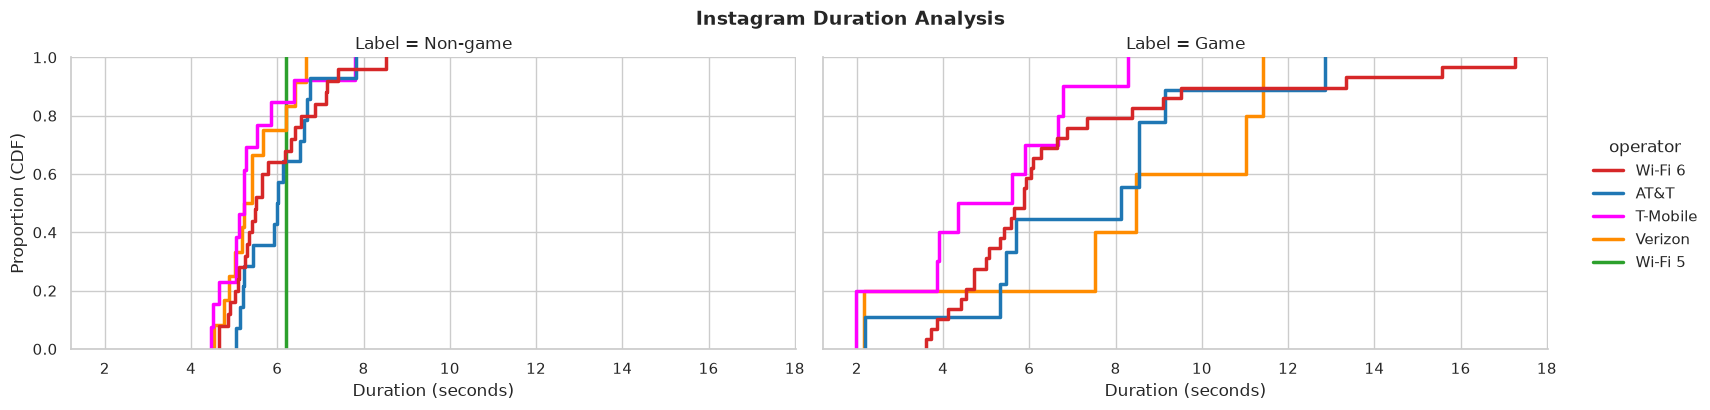

In [41]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Set a clean visual style
# sns.set_theme(style="whitegrid")

# plt.figure(figsize=(8, 5))

# # Plot the Empirical Cumulative Distribution Function (ECDF) split by operator
# sns.ecdfplot(data=combined_instagram_df, x='Duration', hue='operator', linewidth=2.5)

# # Enhance labels and titles
# plt.title('CDF of Instagram Post Duration (Game)', fontsize=14, fontweight='bold', pad=15)
# plt.xlabel('Duration (seconds)', fontsize=12)
# plt.ylabel('Proportion (CDF)', fontsize=12)

# # Adjust layout so nothing gets truncated
# plt.tight_layout()

# # Show or save the plot
# plt.show()
# # plt.savefig('instagram_duration_cdf.png', dpi=300)


# df_operate_ig = combined_instagram_df[combined_instagram_df['Test Status'] == 'Completed'].copy()
df_operate_ig = combined_instagram_df.copy()

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Define your custom color map matching your data's operator names
OP_COLOR_MAP = {
    'AT&T': 'tab:blue', 
    'T-Mobile': 'magenta', 
    'Verizon': 'darkorange',
    'Wi-Fi 6': 'tab:red',       # Added Wi-Fi 6
    'Wi-Fi 5': 'tab:green'      # Added Wi-Fi 5 (Make sure this matches the exact name in your df)
}

# Use displot for faceting with your custom palette
g = sns.displot(
    data=df_operate_ig, 
    x='Duration', 
    hue='operator', 
    # row='Action Type',
    kind="ecdf", 
    linewidth=2.5,
    palette=OP_COLOR_MAP,  # <--- Pass your custom color map here
    height=4,             
    aspect=2,
    col='Label'        
)

# Enhance labels and titles across the grid
g.set_axis_labels("Duration (seconds)", "Proportion (CDF)")
g.fig.suptitle('Instagram Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
# g.set_titles("{row_name}")

plt.show()

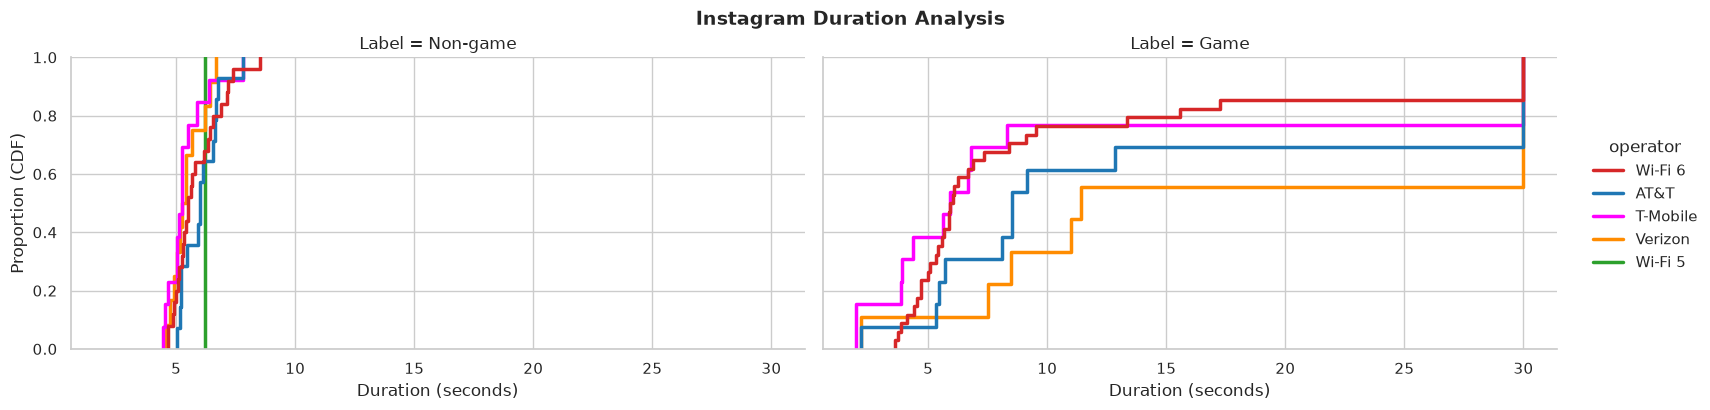

In [42]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Set a clean visual style
# sns.set_theme(style="whitegrid")

# plt.figure(figsize=(8, 5))

# # Plot the Empirical Cumulative Distribution Function (ECDF) split by operator
# sns.ecdfplot(data=combined_instagram_df, x='Duration', hue='operator', linewidth=2.5)

# # Enhance labels and titles
# plt.title('CDF of Instagram Post Duration (Game)', fontsize=14, fontweight='bold', pad=15)
# plt.xlabel('Duration (seconds)', fontsize=12)
# plt.ylabel('Proportion (CDF)', fontsize=12)

# # Adjust layout so nothing gets truncated
# plt.tight_layout()

# # Show or save the plot
# plt.show()
# # plt.savefig('instagram_duration_cdf.png', dpi=300)

import matplotlib.pyplot as plt
import seaborn as sns

# df_operate_ig = combined_instagram_df[combined_instagram_df['Test Status'] == 'Completed'].copy()
df_operate_ig = combined_instagram_df.copy()

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Define your custom color map matching your data's operator names
OP_COLOR_MAP = {
    'AT&T': 'tab:blue', 
    'T-Mobile': 'magenta', 
    'Verizon': 'darkorange',
    'Wi-Fi 6': 'tab:red',       # Added Wi-Fi 6
    'Wi-Fi 5': 'tab:green'      # Added Wi-Fi 5 (Make sure this matches the exact name in your df)
}

# Use displot for faceting with your custom palette
g = sns.displot(
    data=df_operate_ig, 
    x='Duration (fallbacked)', 
    hue='operator', 
    # row='Action Type',
    kind="ecdf", 
    linewidth=2.5,
    palette=OP_COLOR_MAP,  # <--- Pass your custom color map here
    height=4,             
    aspect=2,
    col='Label'        
)

# Enhance labels and titles across the grid
g.set_axis_labels("Duration (seconds)", "Proportion (CDF)")
g.fig.suptitle('Instagram Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
# g.set_titles("{row_name}")

plt.show()

# D2- Whatsapp Overview

In [43]:
# combined_whatsapp_df.head().T

In [44]:
# 1. Define your threshold here
count_threshold = 0  # Change this number to your desired minimum count

# 2. Create the combined column
# df_browsing['PCell+PSCell'] = df_browsing['PCell Band'].astype(str) + ' + ' + df_browsing['PSCell Band'].astype(str)

# 3. Perform the aggregation
summary_whatsapp = combined_whatsapp_df.groupby([
    # 'Test Status',
    # 'PCell+PSCell',
    'Action Type',
    'Label', 'operator',
    # 'Technology'
])[[
    'Send Duration', 
    # 'Delivery Duration', 
    # 'Start Time',
    # 'Receive Time', 
    # 'Transmission Status', 'Delivery Status',
    # 'Delivery Notification', 'Action Type', 'File Size'

]].aggregate([
    'median',
    'count',
    lambda x: x.quantile(0.9),
    # lambda x: x.quantile(0.75),
    # lambda x: x.quantile(0.99)
])

# 4. Filter out rows where the count is less than the threshold
# We check the 'count' column of either metric (e.g., 'Browsing Duration')
summary_whatsapp_filtered = summary_whatsapp.loc[
    summary_whatsapp[('Send Duration', 'count')] >= count_threshold
]

# 5. Display the filtered DataFrame
print(summary_whatsapp)

                               Send Duration                 
                                      median count <lambda_0>
Action Type  Label    operator                               
Send Picture Game     AT&T            2.9190     7    11.6256
                      T-Mobile        2.8890    12    11.9322
                      Verizon         3.9800     5    11.0428
                      Wi-Fi 6         2.4240    33    11.3958
             Non-game AT&T            1.4000    13     1.9574
                      T-Mobile        1.4000    13     1.8440
                      Verizon         1.3970    12     1.6894
                      Wi-Fi 5         1.5590     1     1.5590
                      Wi-Fi 6         1.3800    25     1.7138
Send Text    Game     AT&T            0.6900     9     4.4166
                      T-Mobile        0.4345    12    12.2238
                      Verizon         0.9170     7     9.4340
                      Wi-Fi 6         0.5095    32     1.4251
        

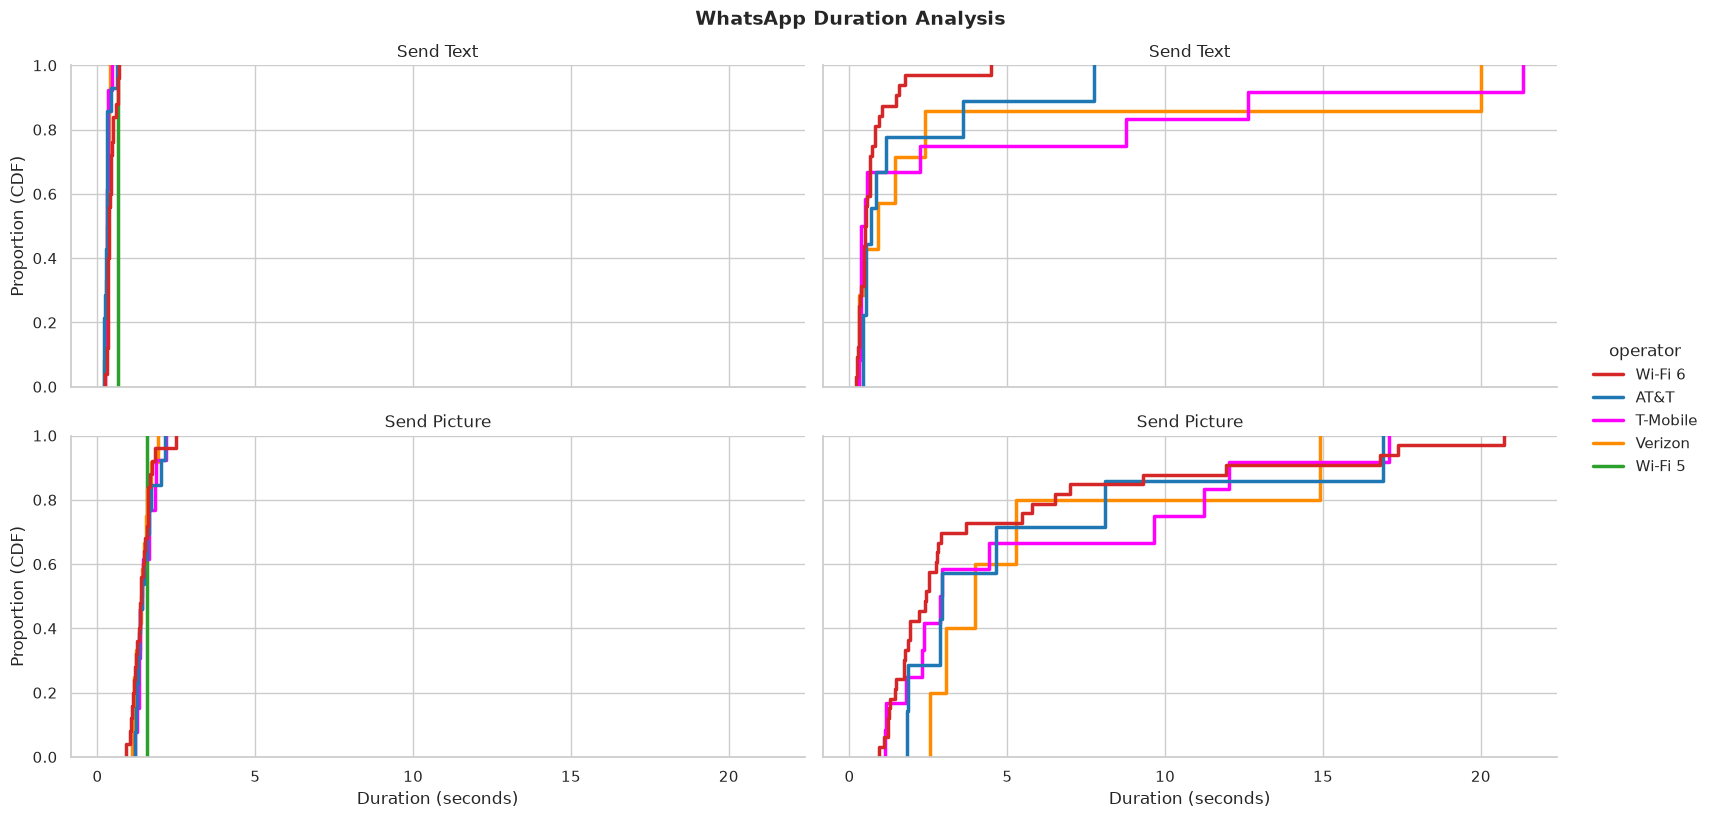

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

df_operate_wa = combined_whatsapp_df[combined_whatsapp_df['Test Status'] == 'Completed'].copy()

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Define your custom color map matching your data's operator names
OP_COLOR_MAP = {
    'AT&T': 'tab:blue', 
    'T-Mobile': 'magenta', 
    'Verizon': 'darkorange',
    'Wi-Fi 6': 'tab:red',       # Added Wi-Fi 6
    'Wi-Fi 5': 'tab:green'      # Added Wi-Fi 5 (Make sure this matches the exact name in your df)
}

# Use displot for faceting with your custom palette
g = sns.displot(
    data=df_operate_wa, 
    x='Send Duration', 
    hue='operator', 
    row='Action Type',
    kind="ecdf", 
    linewidth=2.5,
    palette=OP_COLOR_MAP,  # <--- Pass your custom color map here
    height=4,             
    aspect=2,
    col='Label'        
)

# Enhance labels and titles across the grid
g.set_axis_labels("Duration (seconds)", "Proportion (CDF)")
g.fig.suptitle('WhatsApp Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
g.set_titles("{row_name}")

plt.show()

In [46]:
combined_whatsapp_df[['Label','operator', 'Action Type','Test Status']].value_counts(dropna=False).sort_index()

Label     operator  Action Type   Test Status
Game      AT&T      Send Picture  Completed       7
                                  Failed          6
                    Send Text     Completed       9
                                  Failed          4
          T-Mobile  Send Picture  Completed      12
                                  Failed          1
                    Send Text     Completed      12
                                  Failed          1
          Verizon   Send Picture  Completed       5
                                  Failed          3
                    Send Text     Completed       7
                                  Failed          1
          Wi-Fi 6   Send Picture  Completed      33
                    Send Text     Completed      32
                                  Failed          1
Non-game  AT&T      Send Picture  Completed      13
                                  Failed          1
                    Send Text     Completed      14
          T-Mobile

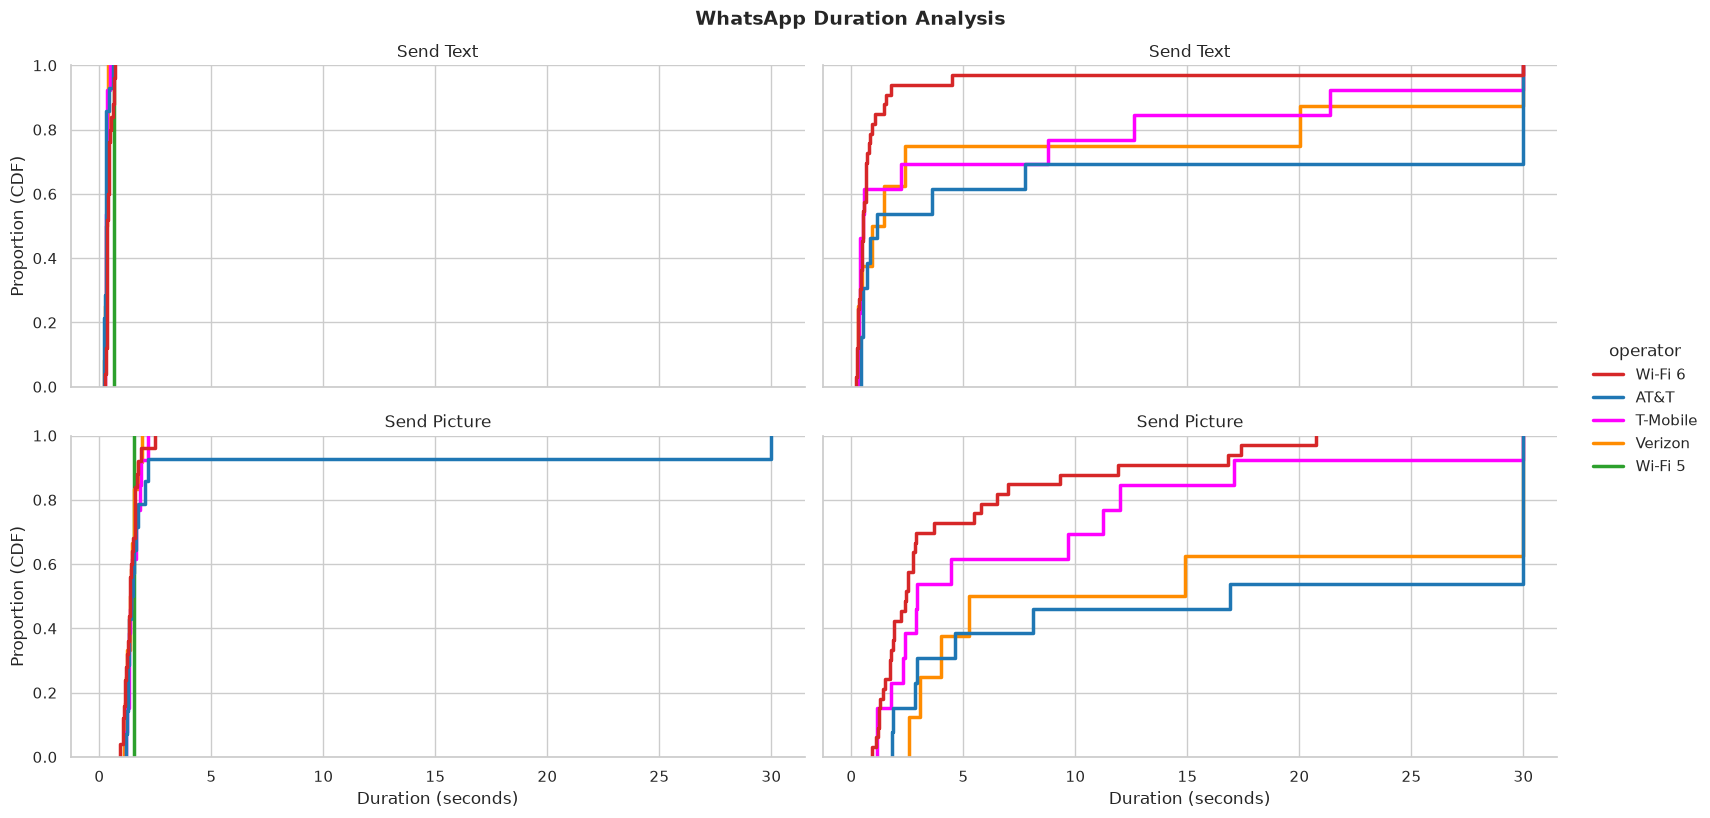

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_operate_wa = combined_whatsapp_df[combined_whatsapp_df['Test Status'] == 'Completed'].copy()
df_operate_wa = combined_whatsapp_df.copy()

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Define your custom color map matching your data's operator names
OP_COLOR_MAP = {
    'AT&T': 'tab:blue', 
    'T-Mobile': 'magenta', 
    'Verizon': 'darkorange',
    'Wi-Fi 6': 'tab:red',       # Added Wi-Fi 6
    'Wi-Fi 5': 'tab:green'      # Added Wi-Fi 5 (Make sure this matches the exact name in your df)
}

# Use displot for faceting with your custom palette
g = sns.displot(
    data=df_operate_wa, 
    x='Duration (fallbacked)', 
    hue='operator', 
    row='Action Type',
    kind="ecdf", 
    linewidth=2.5,
    palette=OP_COLOR_MAP,  # <--- Pass your custom color map here
    height=4,             
    aspect=2,
    col='Label'        
)

# Enhance labels and titles across the grid
g.set_axis_labels("Duration (seconds)", "Proportion (CDF)")
g.fig.suptitle('WhatsApp Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
g.set_titles("{row_name}")

plt.show()

# F- File size

In [48]:
# combined_whatsapp_df.columns
df_operate_wa[['Action Type','Test Status','Transmission Status', 'Delivery Status',]].value_counts()

Action Type   Test Status  Transmission Status  Delivery Status
Send Text     Completed    Successful           Successful         125
Send Picture  Completed    Successful           Successful         121
              Failed       Failed               Failed              11
Send Text     Failed       Failed               Failed               7
Name: count, dtype: int64

In [49]:
combined_whatsapp_df.groupby('Action Type')['File Size'].describe()

,count,mean,std,min,25%,50%,75%,max
Action Type,,,,,,,,
Send Picture,132.0,999135.681818,205.838198,998665.0,999000.5,999096.5,999259.75,999676.0
Send Text,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
combined_whatsapp_df.describe()

,Latitude,Longitude,Send Duration,Delivery Duration,Receive Time,File Size,wifi_connected_primary_freq_mhz,Duration (fallbacked)
count,264.000000,264.000000,246.000000,246.000000,0.0,132.000000,118.000000,264.000000
mean,41.698399,-86.233899,2.096923,2.795138,NaN,999135.681818,6358.813559,3.999405
std,0.000377,0.000660,3.601638,3.567582,NaN,205.838198,271.632197,7.857338
min,41.697936,-86.234780,0.211000,0.276000,NaN,998665.000000,5640.000000,0.211000
25%,41.697986,-86.234505,0.368750,1.283250,NaN,999000.500000,6135.000000,0.377750
50%,41.698363,-86.233419,1.161500,1.876000,NaN,999096.500000,6355.000000,1.227500
75%,41.698833,-86.233259,1.750750,2.587000,NaN,999259.750000,6630.000000,2.183500
max,41.699154,-86.233032,21.350000,21.443000,NaN,999676.000000,6775.000000,30.000000


In [51]:
combined_instagram_df.describe()

,Latitude,Longitude,Host,Duration,Application Throughput,IP Throughput,Max IP Throughput,IP Throughput DL,Max IP Throughput DL,IP Throughput UL,Max IP Throughput UL,Bytes Transferred DL,Bytes Transferred UL,wifi_connected_primary_freq_mhz,Duration (fallbacked)
count,134.000000,134.000000,0.0,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,0.0,134.000000,60.000000,134.000000
mean,41.698399,-86.233908,NaN,6.135246,1460.491356,1052.312000,6680.774034,9142.148949,23073.080678,1052.312000,6680.774034,NaN,999141.544776,6360.083333,8.984769
std,0.000377,0.000660,NaN,2.271784,557.695766,635.662145,3602.820484,7432.473285,17087.887568,635.662145,3602.820484,NaN,204.667698,279.456937,8.054425
min,41.697939,-86.234780,NaN,1.975000,462.794000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,998665.000000,5640.000000,1.975000
25%,41.697988,-86.234505,NaN,5.034500,1199.218000,695.122000,4578.656000,3275.390000,7722.648000,695.122000,4578.656000,NaN,999001.250000,6135.000000,5.108000
50%,41.698363,-86.233886,NaN,5.620500,1422.150500,936.716000,7097.532000,7761.440000,20943.648000,936.716000,7097.532000,NaN,999111.500000,6335.000000,5.884000
75%,41.698832,-86.233277,NaN,6.665500,1587.657750,1350.116000,8397.160000,11313.388000,30773.052000,1350.116000,8397.160000,NaN,999271.250000,6645.000000,7.729500
max,41.699156,-86.233030,NaN,17.269000,4046.299000,3154.328000,18719.712000,32651.096000,74515.448000,3154.328000,18719.712000,NaN,999676.000000,6775.000000,30.000000


# ===============================
# ===============================

# Failed percentage, Whatsapp send picture

In [52]:
# df_browser_merged = combined_whatsapp_df[combined_whatsapp_df['Action Type'] == 'Send Picture']

In [53]:
df_browser_merged = combined_whatsapp_df[combined_whatsapp_df['Action Type'] == 'Send Picture'].copy()

# RAT_COL = 'operator'        ## Change to RAT_COL when we already did the df_browser_merge
# SPLIT_COL = 'Label'
# df_browser_merged['Time To First Byte'] = df_browser_merged['Time To First Byte']/1000
# df_browser_merged.rename(columns={'Round Trip Time (RTT)': 'Round Trip Time'}, inplace=True)

# METRIC_COL = 'Round Trip Time'
# METRIC_COL_UNIT = 'ms'

RAT_COL = 'Label'        ## Change to RAT_COL when we already did the df_browser_merge
SPLIT_COL = 'operator'

# COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
# df_browser_merged = df_browser_merged[df_browser_merged['Host'].isin(COLLECTION_HOST)].copy()

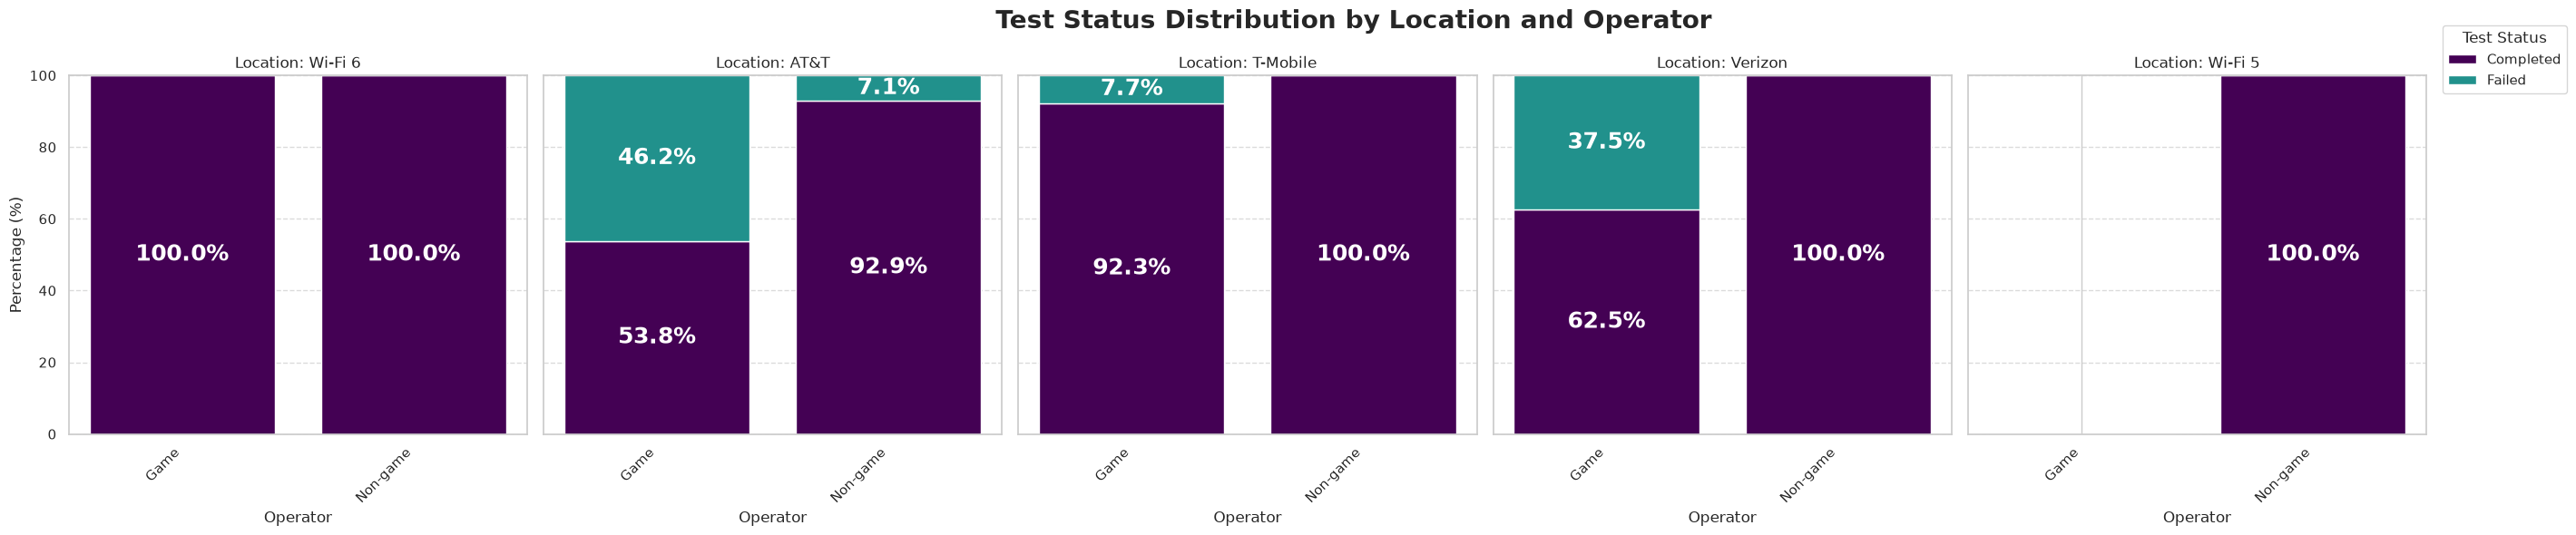

In [54]:
unique_operators = sorted(df_browser_merged[RAT_COL].unique()) # Sort operators
unique_Locations = df_browser_merged[SPLIT_COL].unique()
# unique_Locations = ['Gameday', 'Postgame']

num_Locations = len(unique_Locations)
num_operators = len(unique_operators)

fig, axes = plt.subplots(1, num_Locations, figsize=(num_Locations * 6, 6), sharey=True, squeeze=False)
axes = axes.flatten() # Flatten in case there's only one subplot

all_statuses = df_browser_merged['Test Status'].sort_values().unique()
status_color_map = {status: plt.cm.viridis(i / len(all_statuses)) for i, status in enumerate(all_statuses)}

for c_idx, Location_val in enumerate(unique_Locations):
    ax = axes[c_idx]
    
    operator_x_positions = np.arange(num_operators)
    
    # Prepare data for stacked bars for the current Location
    # This will be a dictionary where keys are statuses and values are lists of percentages for each operator
    stacked_data = {status: [0.0] * num_operators for status in all_statuses}
    
    has_data_for_loc = False
    for op_idx, operator_val in enumerate(unique_operators): # Iterate through sorted operators
        subset_df_browser_merged = df_browser_merged[(df_browser_merged[RAT_COL] == operator_val) & 
                                               (df_browser_merged[SPLIT_COL] == Location_val)]

        if not subset_df_browser_merged.empty:
            has_data_for_loc = True
            status_counts = subset_df_browser_merged['Test Status'].value_counts(normalize=True) * 100
            
            for status in all_statuses:
                stacked_data[status][op_idx] = status_counts.get(status, 0.0)

    if has_data_for_loc:
        bottoms = np.zeros(num_operators)
        for status in all_statuses:
            percentages = stacked_data[status]
            color = status_color_map.get(status, 'gray')
            ax.bar(operator_x_positions, percentages, bottom=bottoms, color=color, edgecolor='white', width=0.8)
            
            # Add percentage labels on bars
            for op_idx, percentage in enumerate(percentages):
                if percentage > 2:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='white', fontsize=18, weight='bold')
                elif percentage > 0:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='black', fontsize=18, weight='bold')
            
            bottoms += np.array(percentages)

        ax.set_xticks(operator_x_positions)
        ax.set_xticklabels(unique_operators, rotation=45, ha='right') # Use sorted unique_operators
        ax.set_title(f'Location: {Location_val}')
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_xlabel('Operator')
    else:
        ax.set_title(f'{Location_val}')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=18, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])

    if c_idx == 0: # Only show y-label on leftmost subplot
        ax.set_ylabel('Percentage (%)')

# Create a single legend for the entire figure
legend_labels = [f'{status}' for status in all_statuses]
legend_handles = [plt.Rectangle((0,0),1,1, fc=status_color_map[status]) for status in all_statuses]

fig.legend(legend_handles, legend_labels, title='Test Status', bbox_to_anchor=(.9, 0.95), loc='upper left', borderaxespad=0.)

fig.suptitle('Test Status Distribution by Location and Operator', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()


In [55]:
df_browser_merged[[
    'Label', 'operator', 
    # 'Test Status'
]].value_counts(dropna=False).sort_index()

Label     operator
Game      AT&T        13
          T-Mobile    13
          Verizon      8
          Wi-Fi 6     33
Non-game  AT&T        14
          T-Mobile    13
          Verizon     12
          Wi-Fi 5      1
          Wi-Fi 6     25
Name: count, dtype: int64

In [56]:
df_browser_merged[[
    'Label', 'operator', 
    'Test Status'
    
]].value_counts(dropna=False).sort_index()

Label     operator  Test Status
Game      AT&T      Completed       7
                    Failed          6
          T-Mobile  Completed      12
                    Failed          1
          Verizon   Completed       5
                    Failed          3
          Wi-Fi 6   Completed      33
Non-game  AT&T      Completed      13
                    Failed          1
          T-Mobile  Completed      13
          Verizon   Completed      12
          Wi-Fi 5   Completed       1
          Wi-Fi 6   Completed      25
Name: count, dtype: int64

# Failed percentage, Whatsapp send text

In [57]:
# df_browser_merged = combined_whatsapp_df[combined_whatsapp_df['Action Type'] == 'Send Picture']

In [58]:
df_browser_merged = combined_whatsapp_df[combined_whatsapp_df['Action Type'] == 'Send Text'].copy()

# RAT_COL = 'operator'        ## Change to RAT_COL when we already did the df_browser_merge
# SPLIT_COL = 'Label'
# df_browser_merged['Time To First Byte'] = df_browser_merged['Time To First Byte']/1000
# df_browser_merged.rename(columns={'Round Trip Time (RTT)': 'Round Trip Time'}, inplace=True)

# METRIC_COL = 'Round Trip Time'
# METRIC_COL_UNIT = 'ms'

RAT_COL = 'Label'        ## Change to RAT_COL when we already did the df_browser_merge
SPLIT_COL = 'operator'

# COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
# df_browser_merged = df_browser_merged[df_browser_merged['Host'].isin(COLLECTION_HOST)].copy()

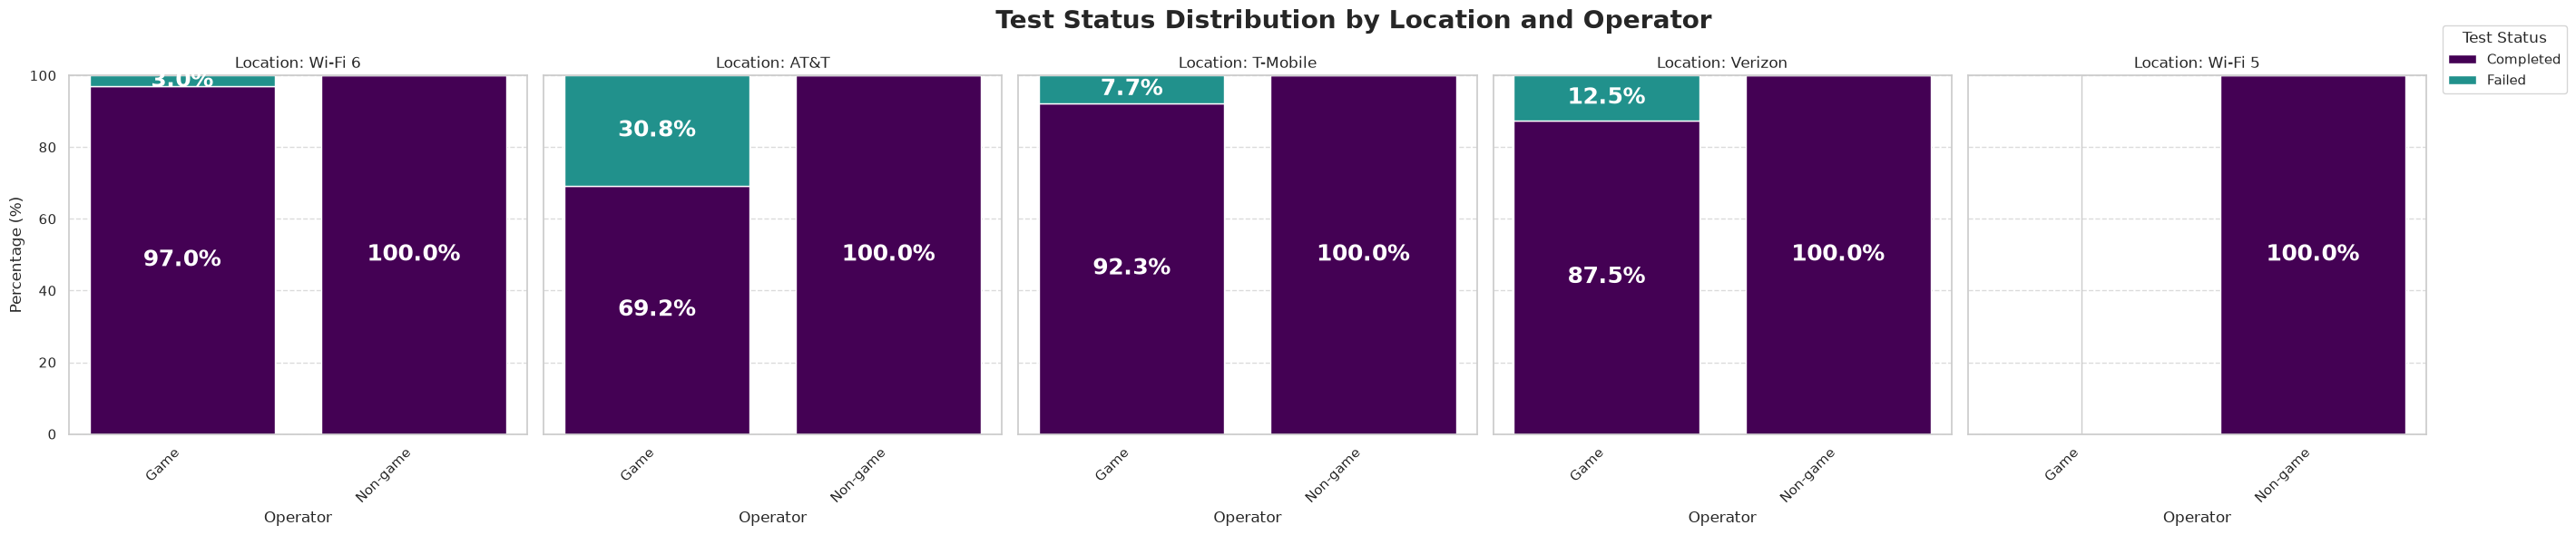

In [59]:
unique_operators = sorted(df_browser_merged[RAT_COL].unique()) # Sort operators
unique_Locations = df_browser_merged[SPLIT_COL].unique()
# unique_Locations = ['Gameday', 'Postgame']

num_Locations = len(unique_Locations)
num_operators = len(unique_operators)

fig, axes = plt.subplots(1, num_Locations, figsize=(num_Locations * 6, 6), sharey=True, squeeze=False)
axes = axes.flatten() # Flatten in case there's only one subplot

all_statuses = df_browser_merged['Test Status'].sort_values().unique()
status_color_map = {status: plt.cm.viridis(i / len(all_statuses)) for i, status in enumerate(all_statuses)}

for c_idx, Location_val in enumerate(unique_Locations):
    ax = axes[c_idx]
    
    operator_x_positions = np.arange(num_operators)
    
    # Prepare data for stacked bars for the current Location
    # This will be a dictionary where keys are statuses and values are lists of percentages for each operator
    stacked_data = {status: [0.0] * num_operators for status in all_statuses}
    
    has_data_for_loc = False
    for op_idx, operator_val in enumerate(unique_operators): # Iterate through sorted operators
        subset_df_browser_merged = df_browser_merged[(df_browser_merged[RAT_COL] == operator_val) & 
                                               (df_browser_merged[SPLIT_COL] == Location_val)]

        if not subset_df_browser_merged.empty:
            has_data_for_loc = True
            status_counts = subset_df_browser_merged['Test Status'].value_counts(normalize=True) * 100
            
            for status in all_statuses:
                stacked_data[status][op_idx] = status_counts.get(status, 0.0)

    if has_data_for_loc:
        bottoms = np.zeros(num_operators)
        for status in all_statuses:
            percentages = stacked_data[status]
            color = status_color_map.get(status, 'gray')
            ax.bar(operator_x_positions, percentages, bottom=bottoms, color=color, edgecolor='white', width=0.8)
            
            # Add percentage labels on bars
            for op_idx, percentage in enumerate(percentages):
                if percentage > 2:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='white', fontsize=18, weight='bold')
                elif percentage > 0:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='black', fontsize=18, weight='bold')
            
            bottoms += np.array(percentages)

        ax.set_xticks(operator_x_positions)
        ax.set_xticklabels(unique_operators, rotation=45, ha='right') # Use sorted unique_operators
        ax.set_title(f'Location: {Location_val}')
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_xlabel('Operator')
    else:
        ax.set_title(f'{Location_val}')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=18, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])

    if c_idx == 0: # Only show y-label on leftmost subplot
        ax.set_ylabel('Percentage (%)')

# Create a single legend for the entire figure
legend_labels = [f'{status}' for status in all_statuses]
legend_handles = [plt.Rectangle((0,0),1,1, fc=status_color_map[status]) for status in all_statuses]

fig.legend(legend_handles, legend_labels, title='Test Status', bbox_to_anchor=(.9, 0.95), loc='upper left', borderaxespad=0.)

fig.suptitle('Test Status Distribution by Location and Operator', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()


In [60]:
df_browser_merged[[
    'Label', 'operator', 
    # 'Test Status'
]].value_counts(dropna=False).sort_index()

Label     operator
Game      AT&T        13
          T-Mobile    13
          Verizon      8
          Wi-Fi 6     33
Non-game  AT&T        14
          T-Mobile    13
          Verizon     12
          Wi-Fi 5      1
          Wi-Fi 6     25
Name: count, dtype: int64

In [61]:
df_browser_merged[[
    'Label', 'operator', 
    'Test Status'
]].value_counts(dropna=False).sort_index()

Label     operator  Test Status
Game      AT&T      Completed       9
                    Failed          4
          T-Mobile  Completed      12
                    Failed          1
          Verizon   Completed       7
                    Failed          1
          Wi-Fi 6   Completed      32
                    Failed          1
Non-game  AT&T      Completed      14
          T-Mobile  Completed      13
          Verizon   Completed      12
          Wi-Fi 5   Completed       1
          Wi-Fi 6   Completed      25
Name: count, dtype: int64

# Failed percentage, Instagram

In [62]:
# df_browser_merged = combined_whatsapp_df[combined_whatsapp_df['Action Type'] == 'Send Picture']

In [63]:
df_browser_merged = combined_instagram_df.copy()

# RAT_COL = 'operator'        ## Change to RAT_COL when we already did the df_browser_merge
# SPLIT_COL = 'Label'
# df_browser_merged['Time To First Byte'] = df_browser_merged['Time To First Byte']/1000
# df_browser_merged.rename(columns={'Round Trip Time (RTT)': 'Round Trip Time'}, inplace=True)

# METRIC_COL = 'Round Trip Time'
# METRIC_COL_UNIT = 'ms'

RAT_COL = 'Label'        ## Change to RAT_COL when we already did the df_browser_merge
SPLIT_COL = 'operator'

# COLLECTION_HOST = ['facebook.com', 'instagram.com', 'ncaa.com', 'sports.yahoo.com', 'tiktok.com']
# df_browser_merged = df_browser_merged[df_browser_merged['Host'].isin(COLLECTION_HOST)].copy()

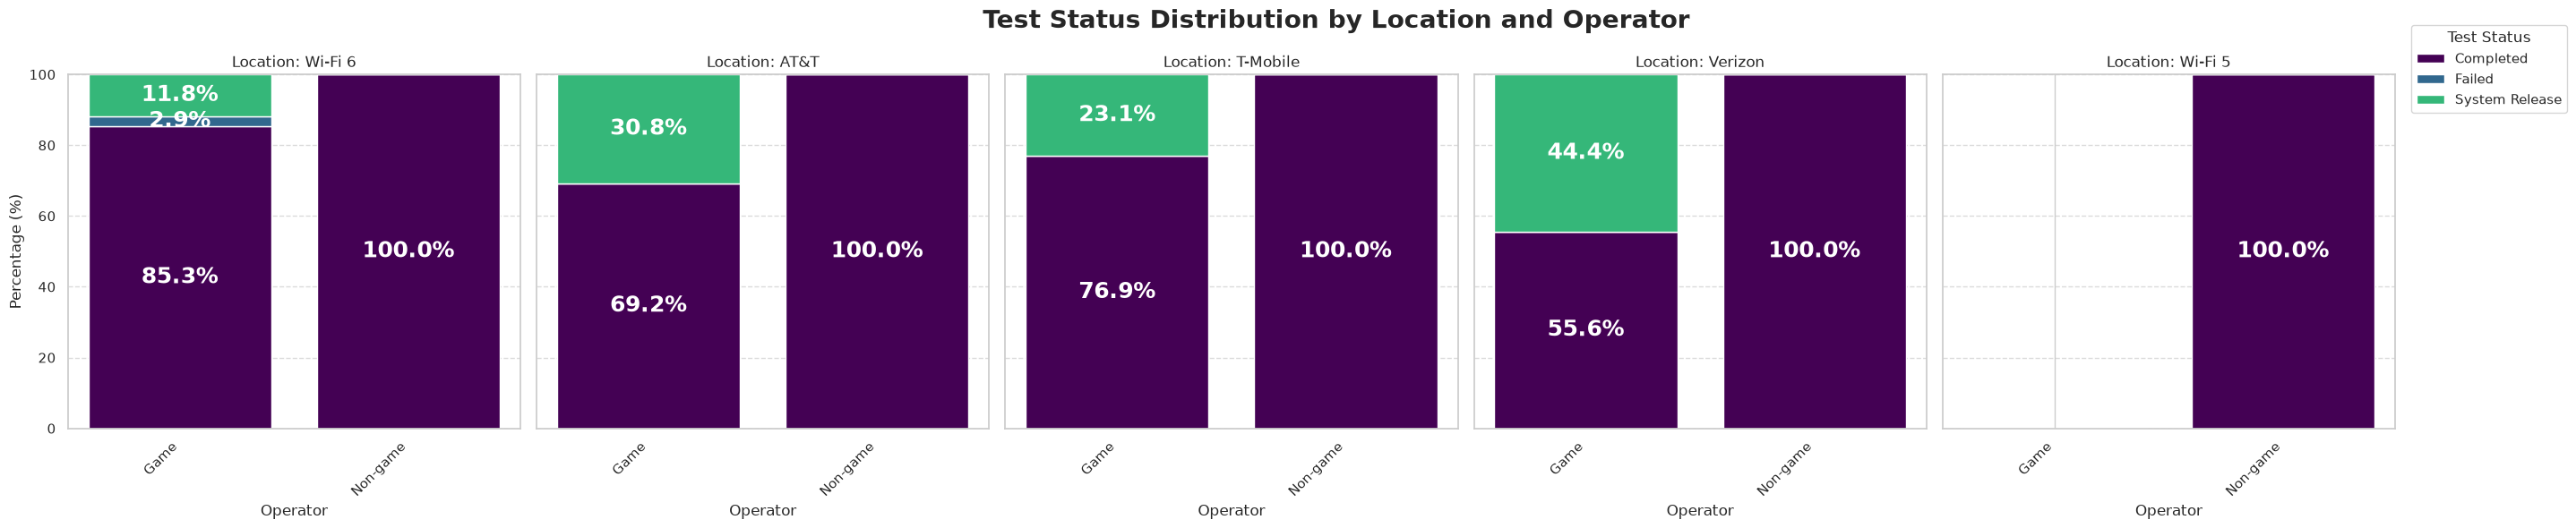

In [64]:
unique_operators = sorted(df_browser_merged[RAT_COL].unique()) # Sort operators
unique_Locations = df_browser_merged[SPLIT_COL].unique()
# unique_Locations = ['Gameday', 'Postgame']

num_Locations = len(unique_Locations)
num_operators = len(unique_operators)

fig, axes = plt.subplots(1, num_Locations, figsize=(num_Locations * 6, 6), sharey=True, squeeze=False)
axes = axes.flatten() # Flatten in case there's only one subplot

all_statuses = df_browser_merged['Test Status'].sort_values().unique()
status_color_map = {status: plt.cm.viridis(i / len(all_statuses)) for i, status in enumerate(all_statuses)}

for c_idx, Location_val in enumerate(unique_Locations):
    ax = axes[c_idx]
    
    operator_x_positions = np.arange(num_operators)
    
    # Prepare data for stacked bars for the current Location
    # This will be a dictionary where keys are statuses and values are lists of percentages for each operator
    stacked_data = {status: [0.0] * num_operators for status in all_statuses}
    
    has_data_for_loc = False
    for op_idx, operator_val in enumerate(unique_operators): # Iterate through sorted operators
        subset_df_browser_merged = df_browser_merged[(df_browser_merged[RAT_COL] == operator_val) & 
                                               (df_browser_merged[SPLIT_COL] == Location_val)]

        if not subset_df_browser_merged.empty:
            has_data_for_loc = True
            status_counts = subset_df_browser_merged['Test Status'].value_counts(normalize=True) * 100
            
            for status in all_statuses:
                stacked_data[status][op_idx] = status_counts.get(status, 0.0)

    if has_data_for_loc:
        bottoms = np.zeros(num_operators)
        for status in all_statuses:
            percentages = stacked_data[status]
            color = status_color_map.get(status, 'gray')
            ax.bar(operator_x_positions, percentages, bottom=bottoms, color=color, edgecolor='white', width=0.8)
            
            # Add percentage labels on bars
            for op_idx, percentage in enumerate(percentages):
                if percentage > 2:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='white', fontsize=18, weight='bold')
                elif percentage > 0:
                    ax.text(operator_x_positions[op_idx], bottoms[op_idx] + percentage / 2, 
                            f'{percentage:.1f}%',
                            ha='center', va='center', color='black', fontsize=18, weight='bold')
            
            bottoms += np.array(percentages)

        ax.set_xticks(operator_x_positions)
        ax.set_xticklabels(unique_operators, rotation=45, ha='right') # Use sorted unique_operators
        ax.set_title(f'Location: {Location_val}')
        ax.set_ylim(0, 100)
        ax.set_yticks(range(0, 101, 20))
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_xlabel('Operator')
    else:
        ax.set_title(f'{Location_val}')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=18, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])

    if c_idx == 0: # Only show y-label on leftmost subplot
        ax.set_ylabel('Percentage (%)')

# Create a single legend for the entire figure
legend_labels = [f'{status}' for status in all_statuses]
legend_handles = [plt.Rectangle((0,0),1,1, fc=status_color_map[status]) for status in all_statuses]

fig.legend(legend_handles, legend_labels, title='Test Status', bbox_to_anchor=(.9, 0.95), loc='upper left', borderaxespad=0.)

fig.suptitle('Test Status Distribution by Location and Operator', fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()


In [65]:
df_browser_merged[[
    'Label', 'operator', 
    # 'Test Status'
]].value_counts(dropna=False).sort_index()

Label     operator
Game      AT&T        13
          T-Mobile    13
          Verizon      9
          Wi-Fi 6     34
Non-game  AT&T        14
          T-Mobile    13
          Verizon     12
          Wi-Fi 5      1
          Wi-Fi 6     25
Name: count, dtype: int64

In [66]:
df_browser_merged[[
    'Label', 'operator', 
    'Test Status'
]].value_counts(dropna=False).sort_index()

Label     operator  Test Status   
Game      AT&T      Completed          9
                    System Release     4
          T-Mobile  Completed         10
                    System Release     3
          Verizon   Completed          5
                    System Release     4
          Wi-Fi 6   Completed         29
                    Failed             1
                    System Release     4
Non-game  AT&T      Completed         14
          T-Mobile  Completed         13
          Verizon   Completed         12
          Wi-Fi 5   Completed          1
          Wi-Fi 6   Completed         25
Name: count, dtype: int64

# ===============================
# ===============================

# Visualization **(USED IN PAPER)**

In [67]:
combined_whatsapp_df['operator'] = combined_whatsapp_df['operator'].replace('Wi-Fi 6', 'Wi-Fi 6 GHz')
combined_whatsapp_df['operator'] = combined_whatsapp_df['operator'].replace('Wi-Fi 5', 'Wi-Fi 5 GHz')

combined_instagram_df['operator'] = combined_instagram_df['operator'].replace('Wi-Fi 6', 'Wi-Fi 6 GHz')
combined_instagram_df['operator'] = combined_instagram_df['operator'].replace('Wi-Fi 5', 'Wi-Fi 5 GHz')

In [68]:
df_operate = combined_whatsapp_df.copy()

In [69]:
OP_COLOR_MAP = {'AT&T': 'tab:blue', 'T-Mobile': 'magenta', 'Verizon': 'darkorange', 'Wi-Fi 5 GHz': 'tab:green', 'Wi-Fi 6 GHz': 'tab:red'}
# OP_COLOR_MAP = 'Set2'
sns.set_style('ticks')

In [70]:
def plot_operator_ecdf(df, x_axis_title, metric_col='Duration (fallbacked)', metric_unit='s', op_color_map=None, file_name='temp'):
    """
    Generates a single ECDF plot grouped by operator with a custom legend containing 
    Median, P90, and completed/total test counts.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The upstream-filtered input dataframe.
    x_axis_title : str
        The label to display on the X-axis.
    metric_col : str, optional
        The column name of the metric to plot. Default is 'Duration (fallbacked)'.
    metric_unit : str, optional
        The unit string for the metric (e.g., 's', 'ms'). Default is 's'.
    op_color_map : dict, optional
        A dictionary mapping operators to specific hex colors.
    """
    # Create a local copy to prevent setting-with-copy warnings
    plot_df = df.copy()
    
    RAT_COL = 'operator'
    COMPLETED_STATUS_VALUE = 'Completed'
    
    # Dynamic column name used for plotting and aggregation
    target_metric_str = f'{metric_col} {metric_unit}'
    plot_df[target_metric_str] = plot_df[metric_col]
    
    # Unique operators list for ordering
    sorted_operators = plot_df[RAT_COL].sort_values().unique().tolist()
    
    # ==========================================
    # 1. Statistical Aggregation
    # ==========================================
    stats_data = plot_df.groupby([RAT_COL]).agg(
        median=(target_metric_str, lambda x: x.quantile(0.50)),
        p90=(target_metric_str, lambda x: x.quantile(0.90)),
        p99=(target_metric_str, lambda x: x.quantile(0.99)),
        completed=('Test Status', lambda x: (x == COMPLETED_STATUS_VALUE).sum()),
        total=('Test Status', 'count')
    ).reset_index()
    
    # ==========================================
    # 2. Plotting (Single ECDF Plot)
    # ==========================================
    g = sns.displot(
        data=plot_df,
        x=target_metric_str,
        kind='ecdf',
        hue=RAT_COL,
        height=4.5,
        aspect=1.6,
        hue_order=sorted_operators,
        palette=op_color_map,
    )
    
    # Extract legend elements created by Seaborn
    legend_handles = g.legend.legend_handles
    legend_labels = [t.get_text() for t in g.legend.get_texts()]
    
    # Target the single axis directly
    ax = g.axes.flat[0]
    
    # Build custom text for the legend box
    labels = []
    for label in legend_labels:
        match = stats_data[stats_data[RAT_COL] == label]
        if not match.empty:
            median = match['median'].iloc[0]
            p90 = match['p90'].iloc[0]
            n_completed = match['completed'].iloc[0]
            n_total = match['total'].iloc[0]
            
            labels.append(f"{label} | n={n_completed}/{n_total} \nMed= {median:.2f} | P90= {p90:.2f}")
        else:
            labels.append(f"{label} | n= 0/0 \n Med= N/A | P90= N/A")
            
    # Apply custom text to the axis legend and remove the default seaborn figure legend
    ax.legend(legend_handles, labels, loc='lower right', reverse=False, fontsize=14, framealpha=0.4, labelspacing=1)
    g.legend.remove()
    
    # ==========================================
    # 3. Aesthetics & Labels
    # ==========================================
    g.set_axis_labels(x_axis_title, "ECDF", fontsize=18, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.xaxis.get_label().set_fontsize(20)
    ax.xaxis.get_label().set_fontweight('bold')
    ax.yaxis.get_label().set_fontsize(20)
    ax.yaxis.get_label().set_fontweight('bold')
    
    plt.xlim(0, 32)
    g.fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.savefig(OUTPUT_DIR / f'{file_name}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

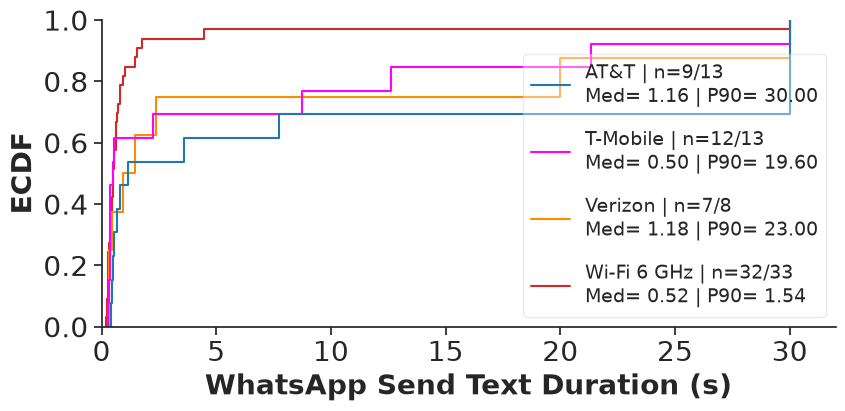

In [71]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = 'Send Text'
VAR_2 = 'Game'

df_operate = combined_whatsapp_df[
    (combined_whatsapp_df['Action Type'] == VAR_1)
    & (combined_whatsapp_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="WhatsApp Send Text Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

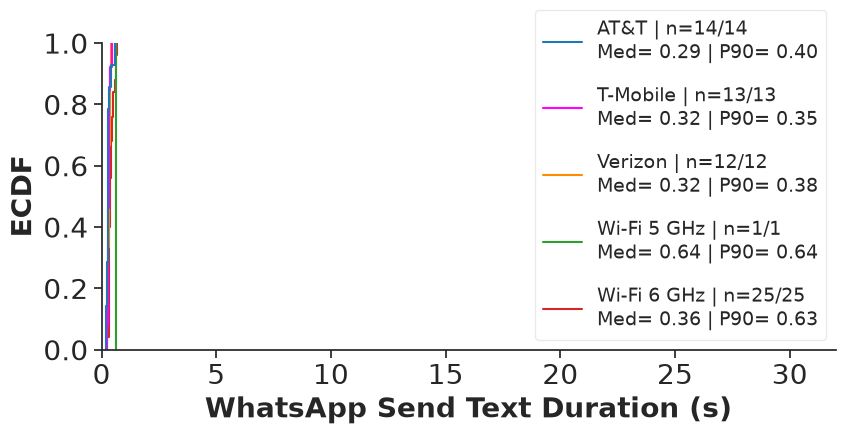

In [72]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = 'Send Text'
VAR_2 = 'Non-game'

df_operate = combined_whatsapp_df[
    (combined_whatsapp_df['Action Type'] == VAR_1)
    & (combined_whatsapp_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="WhatsApp Send Text Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

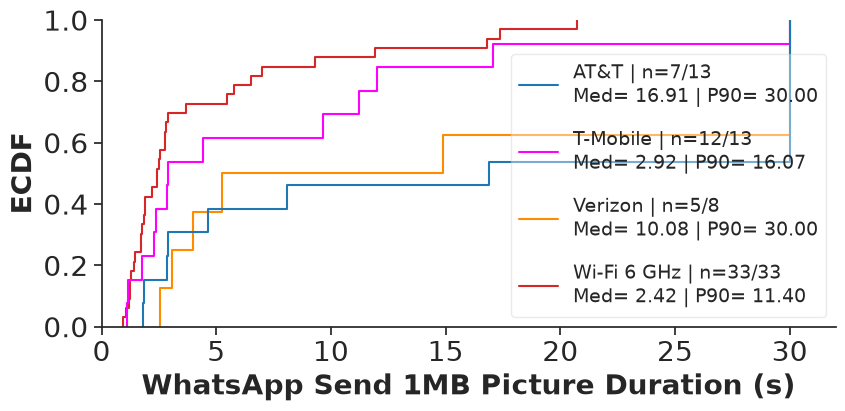

In [73]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = 'Send 1MB Picture'
VAR_2 = 'Game'

df_operate = combined_whatsapp_df[
    (combined_whatsapp_df['Action Type'] == 'Send Picture')
    & (combined_whatsapp_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="WhatsApp Send 1MB Picture Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

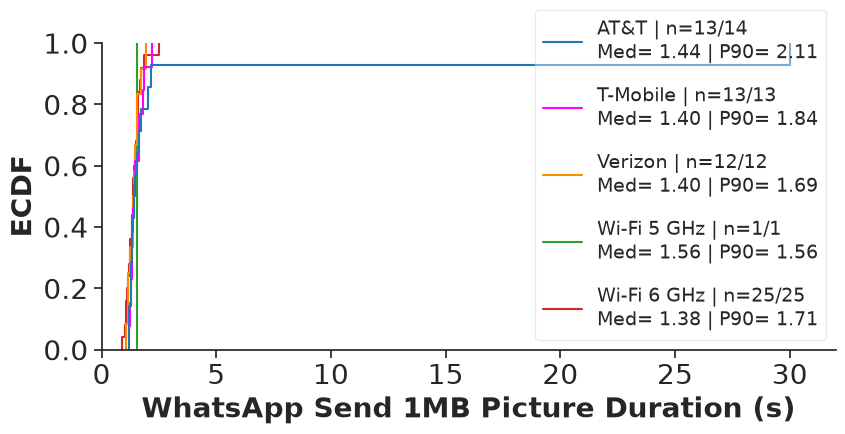

In [74]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = 'Send 1MB Picture'
VAR_2 = 'Non-game'

df_operate = combined_whatsapp_df[
    (combined_whatsapp_df['Action Type'] == 'Send Picture')
    & (combined_whatsapp_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="WhatsApp Send 1MB Picture Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

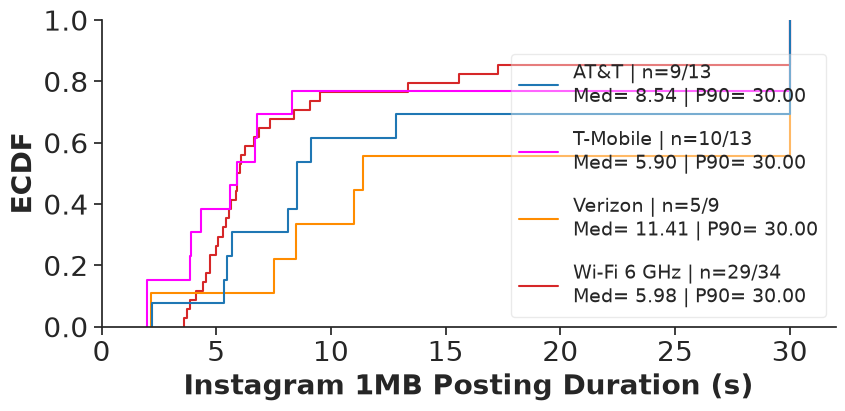

In [75]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = '1MB Posting'
VAR_2 = 'Game'

df_operate = combined_instagram_df[
    # (combined_instagram_df['Action Type'] == VAR_1)
    (combined_instagram_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="Instagram 1MB Posting Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

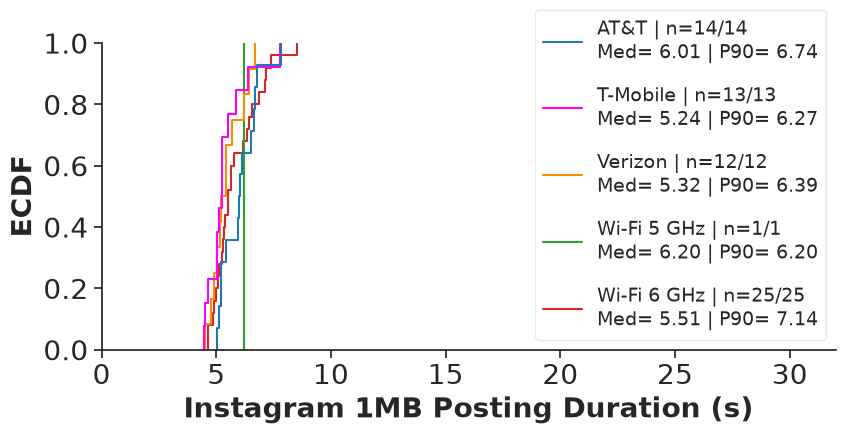

In [76]:
# Call the function by passing your filtered data and custom X-axis label

VAR_1 = '1MB Posting'
VAR_2 = 'Non-game'

df_operate = combined_instagram_df[
    # (combined_instagram_df['Action Type'] == VAR_1)
    (combined_instagram_df['Label'] == VAR_2)
].copy()

plot_operator_ecdf(
    df=df_operate, 
    x_axis_title="Instagram 1MB Posting Duration (s)", 
    op_color_map=OP_COLOR_MAP,
    file_name=f'{VAR_1}-{VAR_2}'
)

# Text output **(USED IN PAPER)**

In [77]:
def get_operator_metrics_text(df, metric_col='Duration (fallbacked)', metric_unit='s'):
    """
    Calculates ECDF statistics grouped by operator and returns a formatted text string
    suitable for feeding into an LLM.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The upstream-filtered input dataframe.
    metric_col : str, optional
        The column name of the metric to analyze. Default is 'Duration (fallbacked)'.
    metric_unit : str, optional
        The unit string for the metric (e.g., 's', 'ms'). Default is 's'.
        
    Returns:
    --------
    str
        A formatted summary text of the metrics.
    """
    RAT_COL = 'operator'
    COMPLETED_STATUS_VALUE = 'Completed'
    
    # Check if the metric column exists to avoid errors
    if metric_col not in df.columns:
        return f"Error: Metric column '{metric_col}' not found in the dataframe."
        
    # ==========================================
    # 1. Statistical Aggregation
    # ==========================================
    stats_data = df.groupby([RAT_COL]).agg(
        median=(metric_col, lambda x: x.quantile(0.50)),
        p90=(metric_col, lambda x: x.quantile(0.90)),
        p99=(metric_col, lambda x: x.quantile(0.99)),
        completed=('Test Status', lambda x: (x == COMPLETED_STATUS_VALUE).sum()),
        total=('Test Status', 'count')
    ).reset_index()
    
    # ==========================================
    # 2. Text Formatting for LLM
    # ==========================================
    output_lines = [
        "### Operator Performance Metrics Summary ###",
        f"Metric Analyzed: {metric_col} ({metric_unit})",
        "--------------------------------------------------"
    ]
    
    for _, row in stats_data.iterrows():
        operator = row[RAT_COL]
        n_completed = row['completed']
        n_total = row['total']
        median_val = row['median']
        p90_val = row['p90']
        p99_val = row['p99']
        
        # Calculate completion rate percentage safely
        completion_rate = (n_completed / n_total * 100) if n_total > 0 else 0
        
        operator_text = (
            f"Operator: {operator}\n"
            f"  - Sample Size (n): {n_completed}/{n_total} completed ({completion_rate:.1f}% completion rate)\n"
            f"  - Median (P50): {median_val:.2f}{metric_unit}\n"
            f"  - P90: {p90_val:.2f}{metric_unit}\n"
            f"  - P99: {p99_val:.2f}{metric_unit}\n"
        )
        output_lines.append(operator_text)
        
    return "\n".join(output_lines)

In [78]:
# Define your test cases configuration
test_cases = [
    {
        "df_source": combined_whatsapp_df,
        "var_1": "Send Text",
        "var_2": "Game",
        "filter_col": "Action Type",
        "filter_val": "Send Text",
        "x_title": "Whatsapp Send Text Duration (s)"
    },
    {
        "df_source": combined_whatsapp_df,
        "var_1": "Send Text",
        "var_2": "Non-game",
        "filter_col": "Action Type",
        "filter_val": "Send Text",
        "x_title": "Whatsapp Send Text Duration (s)"
    },
    {
        "df_source": combined_whatsapp_df,
        "var_1": "Send 1MB Picture",
        "var_2": "Game",
        "filter_col": "Action Type",
        "filter_val": "Send Picture", # Maps to 'Send Picture' in the DF
        "x_title": "Whatsapp Send Picture Duration (s)"
    },
    {
        "df_source": combined_whatsapp_df,
        "var_1": "Send 1MB Picture",
        "var_2": "Non-game",
        "filter_col": "Action Type",
        "filter_val": "Send Picture", # Maps to 'Send Picture' in the DF
        "x_title": "Whatsapp Send Picture Duration (s)"
    },
    {
        "df_source": combined_instagram_df,
        "var_1": "1MB Posting",
        "var_2": "Game",
        "filter_col": None,  # No Action Type filtering for Instagram
        "filter_val": None,
        "x_title": "Instagram Posting Duration (s)"
    },
    {
        "df_source": combined_instagram_df,
        "var_1": "1MB Posting",
        "var_2": "Non-game",
        "filter_col": None,  # No Action Type filtering for Instagram
        "filter_val": None,
        "x_title": "Instagram Posting Duration (s)"
    }
]

# Run the Loop
for case in test_cases:
    df_source = case["df_source"]
    v1 = case["var_1"]
    v2 = case["var_2"]
    f_col = case["filter_col"]
    f_val = case["filter_val"]
    
    # 1. Start with the source DataFrame and filter by Label (Game vs Non-game)
    condition = (df_source['Label'] == v2)
    
    # 2. Dynamically add the 'Action Type' filtering if defined
    if f_col is not None and f_val is not None:
        condition = condition & (df_source[f_col] == f_val)
        
    df_operate = df_source[condition].copy()
    
    # 3. Construct your file name safely
    generated_file_name = f"{v1}-{v2}"
    
    print(f"Processing: {generated_file_name} (Rows: {len(df_operate)})")
    
    # 4. Generate the metric texts for your LLM prompt
    llm_text = get_operator_metrics_text(df_operate)
    print(llm_text)
    print("\n" + "="*50 + "\n")
    
    # Optional: If you still need to plot them using the visual function, 
    # make sure your function accepts 'file_name' and call it here:
    # plot_operator_ecdf(
    #     df=df_operate, 
    #     x_axis_title=case["x_title"], 
    #     op_color_map=OP_COLOR_MAP,
    #     file_name=generated_file_name
    # )

Processing: Send Text-Game (Rows: 67)
### Operator Performance Metrics Summary ###
Metric Analyzed: Duration (fallbacked) (s)
--------------------------------------------------
Operator: AT&T
  - Sample Size (n): 9/13 completed (69.2% completion rate)
  - Median (P50): 1.16s
  - P90: 30.00s
  - P99: 30.00s

Operator: T-Mobile
  - Sample Size (n): 12/13 completed (92.3% completion rate)
  - Median (P50): 0.50s
  - P90: 19.60s
  - P99: 28.96s

Operator: Verizon
  - Sample Size (n): 7/8 completed (87.5% completion rate)
  - Median (P50): 1.18s
  - P90: 23.00s
  - P99: 29.30s

Operator: Wi-Fi 6 GHz
  - Sample Size (n): 32/33 completed (97.0% completion rate)
  - Median (P50): 0.52s
  - P90: 1.54s
  - P99: 21.83s



Processing: Send Text-Non-game (Rows: 65)
### Operator Performance Metrics Summary ###
Metric Analyzed: Duration (fallbacked) (s)
--------------------------------------------------
Operator: AT&T
  - Sample Size (n): 14/14 completed (100.0% completion rate)
  - Median (P50): 0.2